### Imports

In [1]:
from jax import random
from jax import numpy as jnp

import jax

import equinox as eqx
from diffrax import *

from tqdm.auto import tqdm

import optax

import matplotlib.pyplot as plt
import matplotlib

import numpy as np

from functools import partial

from riemannian_dynamics.dynamic import rnn

import riemannian_dynamics as rd
from riemannian_dynamics.plotting import plotting2d, plotting3d, utils

utils.set_font(font_size=18)

#jax.config.update('jax_platforms', 'cpu')
#jax.config.update("jax_default_device", jax.devices('cpu')[0])

In [2]:
cmap_manifold = matplotlib.colormaps['hsv']
cmap_manifold = utils.increase_lightness(cmap_manifold, 0.1)

cmap_e1 = matplotlib.colormaps['hsv']
cmap_e2 = matplotlib.colormaps['hsv']
cmap_traj = matplotlib.colormaps['YlGn']

plotting the colormaps

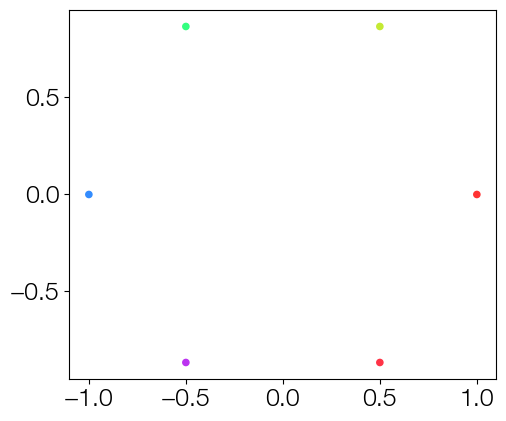

In [3]:
fig = plt.figure()
ax = fig.add_subplot()

ax.set_aspect('equal')

q = 6

ax.scatter(jnp.cos(jnp.linspace(0, 2*jnp.pi, q+1)[:q]), jnp.sin(jnp.linspace(0, 2*jnp.pi, q+1)[:q]), color=cmap_manifold(jnp.linspace(0, 1, q)), s=20)

plt.savefig(f'./plots/targets{q}.pdf')
plt.show()

### RNN definition

In [4]:
key = random.PRNGKey(0)

hidden_dim = 100
input_dims = [2, 1]
neuron_noise = 1.0 # fraction of noise
input_noise = 1.0 # fraction of noise
noise = 0.0
gain = 0.5
activity_l2 = 0.0
final_activation = lambda x: x

training_iterations = 3000
learning_rate = 5*10**-3
weight_decay = 0.0#0.01

min_evidence = 0
max_evidence = jnp.pi*2 # remove last during training
nb_evidence = 7
evidence_duration = 0.5
delay_between_evidence = 0.5
target_dur = evidence_duration+delay_between_evidence

nb_targets = 2

min_delay, max_delay = 0.5, 3.5
nb_delays = 4
delays = jnp.linspace(min_delay, max_delay, nb_delays)

nb_noise = 3

delay_after_go = 0.5
go_duration = 0.5

time_tol = 10**-4

final_time = 4.0

max_times = 2*nb_targets*target_dur + delays + delay_after_go + go_duration + final_time

nb_time = 51

ts = jax.vmap(lambda t: jnp.linspace(0.0, t, nb_time))(max_times)

model = rnn.RNN(jax.random.PRNGKey(0), hidden_dim, input_dims, 2, jax.nn.tanh, gain)

In [5]:
def outer_vmap(fn, n):

    for i in range(n):

        fn = jax.vmap(fn, in_axes=[None]*i + [0] + [None]*(n-i-1))

    return fn

def iterative_vmap(fn, n, in_axes=0):

    for i in range(n): fn = jax.vmap(fn, in_axes=in_axes)

    return fn

# ===== Evidence =====

def get_evidence_input(*evidences):

    nb_targets = len(evidences)

    evidences = [e[:, None] for e in evidences]

    fn = lambda *args: jnp.concatenate(args, axis=-1)

    evidences_vmap = outer_vmap(fn, nb_targets)(*evidences) # 11 x 11 x 2

    fn = lambda evidence: jnp.stack([evidence, *2*[jnp.zeros_like(evidence)]], axis=-2)

    evidences_vmap = jnp.stack([jnp.cos(evidences_vmap), jnp.sin(evidences_vmap)], axis=-1)

    evidence_points = jax.vmap(jax.vmap(fn))(evidences_vmap)#.reshape(*nb_targets*[nb_evidence], -1, 2)
    evidence_points = evidence_points.reshape(*[e.shape[0] for e in evidences], -1, 2)

    fn = lambda shift: jnp.array([shift, evidence_duration+shift, target_dur+shift-10**-6])
    evidence_times = jax.vmap(fn)(jnp.arange(0, target_dur*nb_targets, target_dur)).reshape(-1)

    evidence_times = jnp.concatenate([evidence_times, max_times[-1:]+time_tol])
    evidence_points = jnp.concatenate([evidence_points, jnp.zeros_like(evidence_points)[..., :1, :]], axis=-2)

    evidence_ts, evidence_pts = iterative_vmap(rectilinear_interpolation, nb_targets, in_axes=(None, 0))(evidence_times, evidence_points)
    evidence_input = iterative_vmap(LinearInterpolation, nb_targets)(evidence_ts, evidence_pts)
    return evidence_input, evidence_times, evidence_points

# ===== Target =====
def get_target_output(evidence_points):
    target_times = evidence_times[None, :] + delays[:, None] + nb_targets*target_dur + go_duration + delay_after_go
    target_times = target_times.at[:, -1].set(target_times[:, -1]+time_tol)
    target_times = jnp.concatenate([jnp.zeros_like(target_times)[..., :1], target_times], axis=-1)
    target_points = jnp.concatenate([jnp.zeros_like(evidence_points)[..., :1, :], evidence_points], axis=-2)

    target_ts, target_pts = jax.vmap(iterative_vmap(rectilinear_interpolation, nb_targets, in_axes=(None, 0)), in_axes=(0, None))(target_times, target_points)

    target_output = iterative_vmap(LinearInterpolation, nb_targets+1)(target_ts, target_pts)

    return target_times, target_output

In [6]:
evidences = jnp.linspace(min_evidence, max_evidence, nb_evidence)[:-1]
evidence_input, evidence_times, evidence_points = get_evidence_input(*nb_targets*[evidences])

target_times, target_output = get_target_output(evidence_points)

# ===== Go cue =====
go_start = nb_targets*target_dur + delays
go_points = jnp.array([0.0, 1.0, 0.0, 0.0])[:, None]
go_times =  jax.vmap(lambda t, u: jnp.array([0.0, t, t+go_duration, u]))(go_start, max_times)
go_times = go_times.at[:, -1].set(go_times[:, -1]+time_tol)
go_ts, go_pts = jax.vmap(rectilinear_interpolation, in_axes=(0, None))(go_times, go_points)
go_input = jax.vmap(LinearInterpolation)(go_ts, go_pts)

discontinuities = jnp.concatenate([target_times, go_times, jnp.tile(evidence_times, (nb_delays, 1))], axis=-1)
discontinuities = jnp.sort(discontinuities, axis=-1)

# Load model

In [7]:
def save(filename, model):
    with open(filename, "wb") as f:
        eqx.tree_serialise_leaves(f, model)

def load(filename, model):
    with open(filename, "rb") as f:
        model = eqx.tree_deserialise_leaves(f, model)

    return model

model = load('./models/submission/model.eqx', model) ; training_iterations = 0
#save("./models/model_final.eqx", model)

# Solve

In [8]:
@eqx.filter_jit
def solve(key, model, go_input, evidence_input, ts, discontinuity, noise):

    key, k1, k2, k3 = random.split(key, 4)
    bm = VirtualBrownianTree(shape=(hidden_dim,), t0=0.0, t1=ts[-1], tol=10**-2, key=k1)
    bm_input1 = VirtualBrownianTree(shape=(2,), t0=0.0, t1=ts[-1], tol=10**-2, key=k2)

    terms = [ODETerm(model.f()),
             ODETerm(lambda t, x, args: model.g_i(0)(t, x, args) @ evidence_input.evaluate(t)),
             ODETerm(lambda t, x, args: model.g_i(1)(t, x, args) @ go_input.evaluate(t)),
             ]

    if noise != 0:
        terms = terms + [#ControlTerm(model.h_sigma(noise*neuron_noise), bm),
                         ControlTerm(model.h_g_i(0, noise*input_noise), bm_input1),
                         ]

    terms = MultiTerm(*terms)

    sol = diffeqsolve(terms, Heun(), 0.0, ts[-1], 0.1, model.x0(),
                       saveat=SaveAt(ts=ts),
                       #stepsize_controller=PIDController(rtol=10**-2, atol=10**-3, jump_ts=discontinuity),
                      max_steps=10000
                      )

    return sol.ys

In [9]:
solve_vmap = eqx.filter_vmap(eqx.filter_vmap(eqx.filter_vmap(eqx.filter_vmap(solve,
                                                                            in_axes=(None, None, None, 0, None, None, None)),
                                                                            in_axes=(None, None, None, 0, None, None, None)),
                                                                            in_axes=(None, None, 0, None, 0, 0, None)),
                                                                            in_axes=(0, None, None, None, None, None, None))

# Evaluate inputs

In [10]:
def evaluate_(path, ts):

    return eqx.filter_vmap(path.evaluate)(ts)

In [11]:
ys = jax.vmap(iterative_vmap(evaluate_, nb_targets, in_axes=(0, None)))(target_output, ts)
ds = iterative_vmap(evaluate_, nb_targets, (0, None))(evidence_input, ts[-1])
gs = eqx.filter_vmap(evaluate_, in_axes=(0, 0))(go_input, ts)

print(f'ys: {ys.shape}, ds: {ds.shape}, gs: {gs.shape}')

ys: (4, 6, 6, 51, 2), ds: (6, 6, 51, 2), gs: (4, 51, 1)


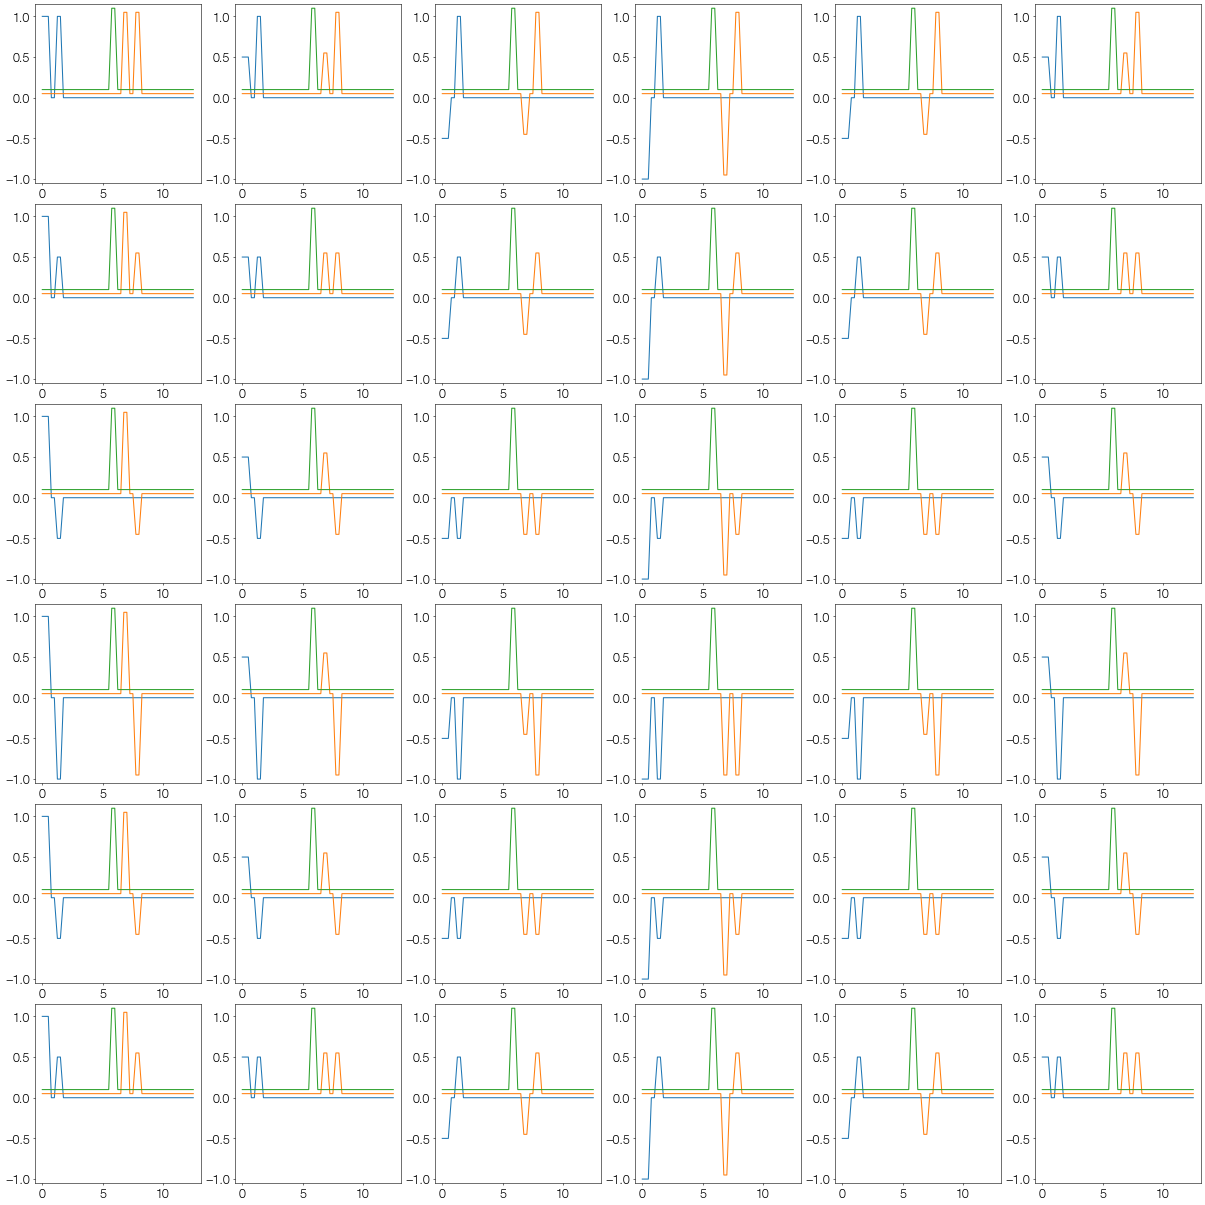

In [12]:
axs, _, fig = utils.get_ax_gridspec(ds.shape[0], ds.shape[1], dpi=50)

delay_id = -1

for i, ax_ in enumerate(axs):
    for j, ax in enumerate(ax_):
        ax.plot(ts[delay_id], ds[j, i, :, 0], label=(None if i!=0 or j!=0 else 'Input'))
        ax.plot(ts[delay_id], ys[delay_id, j, i, :, 0]+0.05, label=(None if i!=0 or j!=0 else 'Output'))
        ax.plot(ts[delay_id], gs[delay_id, :, 0]+0.1, label=(None if i!=0 or j!=0 else 'Go'))
        ax.set_ylim(-1.05, 1.15)

plt.savefig('./plots/example_input_output_go.pdf')
plt.show()

# Training

In [13]:
def loss_(model, xs, ys):

    ys_hat = final_activation(model.d(xs))

    mask_nonzero = (jnp.sum(ys**2, axis=-1) != 0.0)
    mask_zero = (ts <= go_times[:, 1:2]) | (ts >= (max_times[:, None] - final_time))

    dy_yhat = ((ys - ys_hat)**2)*mask_nonzero[..., None]
    dy = (ys_hat**2)*mask_zero[None, :, *nb_targets*[None], :, None]
    dx = (xs**2)*mask_zero[None, :, *nb_targets*[None], :, None]

    return (jnp.mean(dy)/jnp.mean(mask_zero)
            + jnp.mean(dy_yhat)/jnp.mean(mask_nonzero)
            #+ 0.01*jnp.mean(dx)/jnp.mean(mask_zero)
            +activity_l2*jnp.mean(dx**2)
            )

@eqx.filter_jit
def loss(model, key, rotation=True):

    if rotation:
        key, subkey = random.split(key)
        A = random.normal(subkey, (*evidence_input.ys.shape[:2], 2, 2))
        R = jax.scipy.linalg.expm(A - A.transpose((0, 1, 3, 2)))

        evidence_input_ = eqx.tree_at(lambda x: x.ys, evidence_input, jnp.matmul(evidence_input.ys, R[:, : None]))
        ys_ = jnp.matmul(ys[..., None, :], R[None, :, :, None])[..., 0, :] * ((ys**2).sum(axis=-1, keepdims=True) != 0)

    else:
        evidence_input_ = evidence_input
        ys_ = ys

    keys = random.split(key, nb_noise)

    xs = solve_vmap(keys, model, go_input, evidence_input_, ts, discontinuities, noise)

    return loss_(model, xs, ys_)

@eqx.filter_jit
def loss_test(model):

    keys = random.PRNGKey(0)[None]

    xs = solve_vmap(keys, model, go_input, evidence_input, ts, discontinuities, 0.0)

    return loss_(model, xs, ys)

@eqx.filter_jit
def step(key, model, optim, opt_state):

    l_test = loss_test(model)

    l_train, grads = eqx.filter_value_and_grad(loss)(model, key)

    updates, opt_state = optim.update(grads, opt_state, model)

    model = eqx.apply_updates(model, updates)

    return model, l_train, l_test, opt_state

In [14]:
iterator = tqdm(range(training_iterations))

optim = optax.adamw(learning_rate=learning_rate, weight_decay=weight_decay) if weight_decay is not None else optax.adam(learning_rate=learning_rate)

opt_state = optim.init(eqx.filter(model, eqx.is_array))

losses = []

for iteration in iterator:

    key, subkey = random.split(key)
    model, l_train, l_test, opt_state = step(subkey, model, optim, opt_state)

    losses.append([l_train, l_test])

    iterator.set_description(f"Train loss: {l_train:.6f}, Test loss: {l_test:.6f}")

losses = jnp.array(losses)

0it [00:00, ?it/s]

# Some plotting

In [15]:
evidences_test = jnp.linspace(min_evidence, max_evidence, 7)[:-1]

evidence_input_test, _, evidence_points_test = get_evidence_input(*nb_targets*[evidences_test])
_, target_output_test = get_target_output(evidence_points_test)

ts_test = jax.vmap(lambda t: jnp.linspace(0.0, t, 201))(max_times)

xs = solve_vmap(random.PRNGKey(0)[None], model, go_input, evidence_input_test, ts_test, discontinuities, 0.0)[0]
ys_hat = final_activation(model.d(xs))

# =====
ys = jax.vmap(iterative_vmap(evaluate_, nb_targets, in_axes=(0, None)))(target_output_test, ts_test)
ds = iterative_vmap(evaluate_, nb_targets, (0, None))(evidence_input_test, ts_test[0])
gs = eqx.filter_vmap(evaluate_, in_axes=(0, 0))(go_input, ts_test)

print(f'ys: {ys.shape}, ds: {ds.shape}, gs: {gs.shape}')

ys: (4, 6, 6, 201, 2), ds: (6, 6, 201, 2), gs: (4, 201, 1)


### Example output

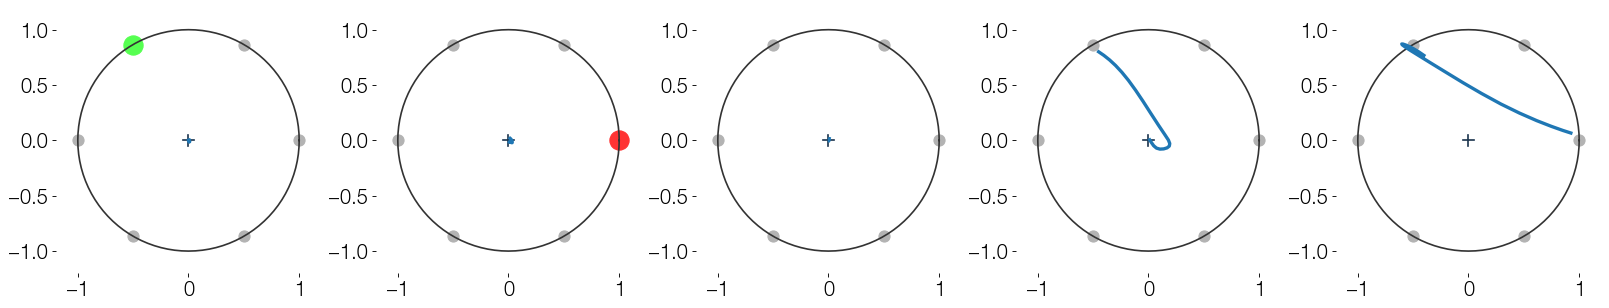

In [19]:
axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, nb_targets*2+1, cols_3d=(), dpi=80)

evidence_ids = (jnp.arange(1, nb_evidence*4, 2)%nb_evidence)[:nb_targets]
evidence_ids = [0, 2] # note: swapped
delay_id = 1

for ax_ in axs.T:
    for ax in ax_:

        # ==== Possible targets =====

        thetas = jnp.linspace(0, 2*jnp.pi, nb_evidence)[:-1]
        ax.scatter(jnp.cos(thetas), jnp.sin(thetas), color=(0.7, 0.7, 0.7), s=100)
        #ax.scatter(0.0, 0.0, color=(0.1, 0.2, 0.3))
        ax.plot([-0.05, 0.05], [0.0, 0.0], color=(0.1, 0.2, 0.3), zorder=1)
        ax.plot([0.0, 0.0], [-0.05, 0.05], color=(0.1, 0.2, 0.3), zorder=1)

        ax.set_aspect('equal')

        ax.plot(jnp.cos(jnp.linspace(0, 2*jnp.pi, 101)), jnp.sin(jnp.linspace(0, 2*jnp.pi, 101)), color=(0.2, 0.2, 0.2))

        utils.remove_axes(ax)
        ax.set_xlim(-1.2, 1.2), ax.set_ylim(-1.2, 1.2)

    for i in range(nb_targets):
        # ==== Current targets =====
        th = evidences[evidence_ids[nb_targets-i-1]]
        ax_[i].scatter(jnp.cos(th), jnp.sin(th), color=cmap_manifold(th/(jnp.pi*2)), s=300)

        # ==== Input Trajectory =====
        time_mask = (i*target_dur <= ts_test[delay_id]) & (ts_test[delay_id] <= (i+1)*target_dur)
        ax_[i].plot(ys_hat[delay_id, *evidence_ids, time_mask, 0],
                    ys_hat[delay_id, *evidence_ids, time_mask, 1], linewidth=3.0)

        # ==== Output Trajectory =====
        temp = delays[delay_id]
        time_mask = (((nb_targets+i)*target_dur+temp <= ts_test[delay_id])
                     & (ts_test[delay_id] <= (nb_targets+i+1)*target_dur+temp+0.1))

        ax_[i+nb_targets+1].plot(ys_hat[delay_id, *evidence_ids, time_mask, 0],
                                 ys_hat[delay_id, *evidence_ids, time_mask, 1], linewidth=3.0)
        #ax_[i+nb_targets+1].plot(ys_hat[delay_id, *evidence_ids, :, 0],
        #                         ys_hat[delay_id, *evidence_ids, :, 1], linewidth=2.0, alpha=0.1, color=(0, 0, 0))

    # ==== Delay Trajectory =====
    i = nb_targets//2 + 1

    time_mask = ((nb_targets*target_dur <= ts_test[delay_id]) &
                 (ts_test[delay_id] <= nb_targets*target_dur+delays[delay_id]))
    ax_[i].plot(ys_hat[delay_id, *evidence_ids, time_mask, 0], ys_hat[delay_id, *evidence_ids, time_mask, 1], linewidth=2.0)

plt.savefig('./plots/example_trials.pdf')
plt.show()

Several useful plots

(28944, 4) (4, 6, 6, 201, 3)


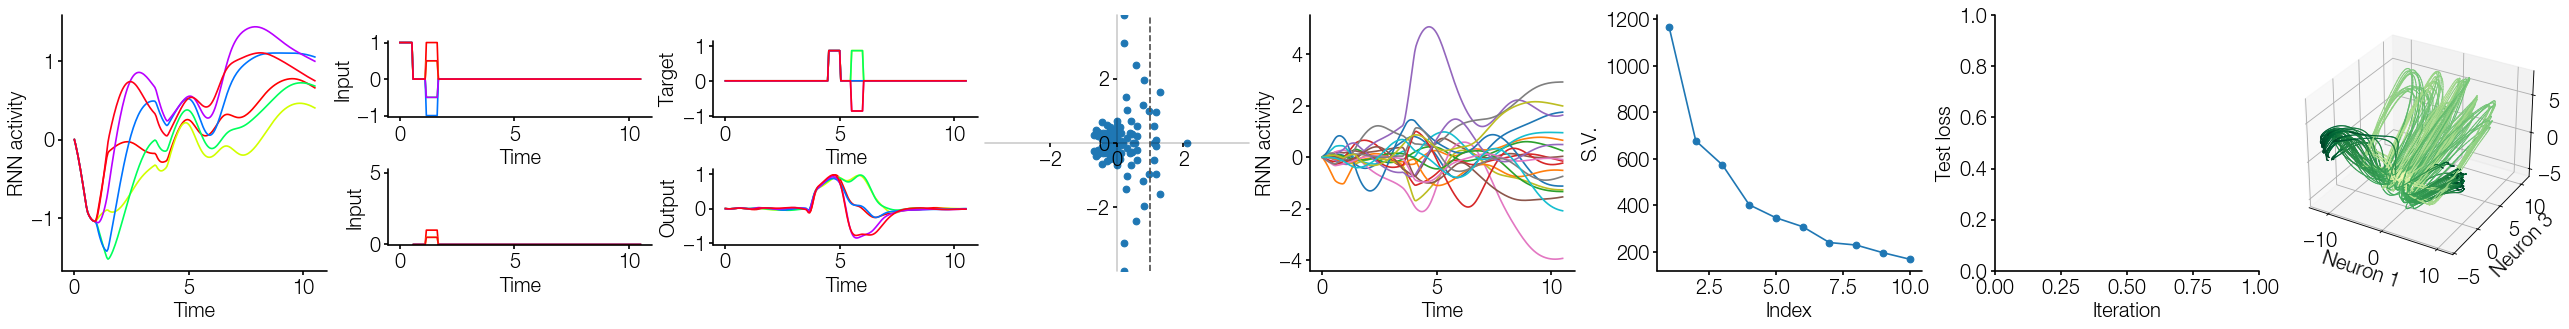

In [17]:
axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, 8, cols_3d=(7,), dpi=80)

evidence_id = 2

for ax_ in axs.T:

    # ===== Time series =====
    ax = ax_[0]
    colors = cmap_e2((evidences_test-jnp.min(evidences_test))/(jnp.max(evidences_test)-jnp.min(evidences_test)))
    for i in range(xs.shape[1]):
        ax.plot(ts_test[delay_id], xs[delay_id, i, evidence_id, :, 1], color=colors[i])

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('RNN activity')

    # ===== evidence input =====
    ax = ax_[1]

    axs_ = utils.add_vertical_axes(ax, 2, spacing=0.2)

    ax = axs_[0]
    colors = cmap_e1((evidences_test-jnp.min(evidences_test))/(jnp.max(evidences_test)-jnp.min(evidences_test)))
    for i in range(ds.shape[0]):
        ax.plot(ts_test[delay_id], ds[i, 0, :, 0], color=colors[i])

    ax.set_ylim(-1.05, 1.05)

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('Input')

    # ===== Go input =====
    ax = axs_[1]
    colors = cmap_e2((evidences_test-jnp.min(evidences_test))/(jnp.max(evidences_test)-jnp.min(evidences_test)))
    for i in range(ds.shape[0]):
        ax.plot(ts_test[delay_id], ds[i, evidence_id, :, 0], color=colors[i])

    ax.set_ylim(evidences[0]-0.05, evidences[-1]+0.05)

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('Input')

    # ===== Target output =====
    ax = ax_[2]

    axs_ = utils.add_vertical_axes(ax, 2, spacing=0.2)

    ax = axs_[0]
    for i in range(ys.shape[1]):
        ax.plot(ts_test[delay_id], ys[delay_id, i, evidence_id, :, 1], color=colors[i])

    ax.set_ylim(-1.05, 1.15)

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('Target')

    # ===== RNN output =====
    ax = axs_[1]
    for i in range(ys.shape[1]):
        ax.plot(ts_test[delay_id], ys_hat[delay_id, i, evidence_id, :, 1], color=colors[i])

    ax.set_ylim(-1.05, 1.15)

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('Output')

    # ===== Eig =====
    ax = ax_[3]

    L, V = np.linalg.eig(model.W)

    ax.scatter(L.real, L.imag)

    ax.axvline(1.0, linestyle='--', color=(0.3, 0.3, 0.3))

    utils.set_centered_axes(ax)
    rmax = jnp.max(jnp.abs(L))
    ax.set_xlim(-rmax, rmax), ax.set_ylim(-rmax, rmax)

    # ===== Couple of neurons =====
    ax = ax_[4]

    colors = cmap_e1((evidences-jnp.min(evidences))/(jnp.max(evidences)-jnp.min(evidences)))
    for i in range(20):
        ax.plot(ts_test[delay_id], xs[delay_id, 0, evidence_id, :, i])

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Time'), ax.set_ylabel('RNN activity')

    # ===== S.V. =====
    ax = ax_[5]

    S = jnp.linalg.svd(xs.reshape(-1, xs.shape[-1]), full_matrices=False, compute_uv=False)

    ax.plot(jnp.arange(10)+1, S[:10], '-o')

    #ax.set_yscale('log')

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Index'), ax.set_ylabel('S.V.')


    # ===== Loss =====
    ax = ax_[6]

    if len(losses) != 0:
        ax.plot(losses[:, 1])

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Iteration'), ax.set_ylabel('Test loss')


    # ===== 3D plot =====
    ax = ax_[7]

    xs_centered = xs - jnp.mean(xs, axis=(0, 1, 2, 3))
    _, _, V = jnp.linalg.svd(xs_centered.reshape(-1, xs_centered.shape[-1]), full_matrices=False)
    xs_pca = xs_centered @ V[:3].T

    x = xs_pca[:, :, :, :]#[:, evidence_id:evidence_id+2, evidence_id:evidence_id+2, 20:22]
    t = ts_test[delay_id, :]#[20:22]

    ts_normalized = t/jnp.max(t)
    ts_normalized = np.broadcast_to(ts_normalized[None, None, None, :, None], x.shape)
    colors = matplotlib.colormaps['pink_r'](ts_normalized).reshape(-1, 3, 4)[:, 0, :]
    #colors[..., 3] = 1.0

    print(colors.shape, xs_pca.shape)
    cmap = matplotlib.colormaps['Greys']

    #ax.scatter(*x.reshape(-1, x.shape[-1]).T, c=colors, s=2, linewidth=0.0, alpha=0.2)
    for k, cmap in enumerate([cmap_e1, cmap_e2]):
        for i in range(xs.shape[1]):
            for j in range(xs.shape[2]):
                #ax.plot(*x[k, i, j].T, color=cmap((i+1)/nb_evidence), alpha=0.5)
                plotting3d.plot_with_gradient_3d(ax, *x[k, i, j].T,
                                                 cmap=cmap_traj, gradient=np.linspace(0.1, 1.0, len(t)), linewidth=1.0, alpha=0.99)

    ax.view_init(30, -60, 0)

    utils.set_bottom_left_axis(ax)
    ax.set_xlabel('Neuron 1'), ax.set_ylabel('Neuron 2'), ax.set_ylabel('Neuron 3')

plt.savefig('./plots/wm_main.pdf')

plt.show()

### Metric

In [18]:
evidences_test = jnp.linspace(min_evidence, max_evidence, 21)#[:-1]

evidence_input_test, _, evidence_points_test = get_evidence_input(*nb_targets*[evidences_test])
_, target_output_test = get_target_output(evidence_points_test)

xs = solve_vmap(random.PRNGKey(0)[None], model, go_input, evidence_input_test, ts_test, discontinuities, 0.0)[0]
ys_hat = final_activation(model.d(xs))

# =====
ys = jax.vmap(iterative_vmap(evaluate_, nb_targets, in_axes=(0, None)))(target_output_test, ts_test)
ds = iterative_vmap(evaluate_, nb_targets, (0, None))(evidence_input_test, ts_test[0])
gs = eqx.filter_vmap(evaluate_, in_axes=(0, 0))(go_input, ts_test)

In [20]:
delay_id = nb_delays-1

go_input_delay_id = eqx.tree_at(lambda t: t.ts, go_input, go_input.ts[delay_id:delay_id+1])
go_input_delay_id = eqx.tree_at(lambda t: t.ys, go_input_delay_id, go_input.ys[delay_id:delay_id+1])

def ivmap(fn, i):
    for _ in range(i):
        fn = jax.vmap(fn)
    return fn

def nvmap(fn, n, nb_arguments):
    fn = jax.vmap(fn, in_axes=[None]*n + [0] + [None]*(nb_arguments-n-1))
    return fn

def solve_vmap_evidence_(*evidences):

    evidences = [e[None] for e in evidences]

    evidence_input_test, _, evidence_points_test = get_evidence_input(*evidences)

    return solve_vmap(random.PRNGKey(0)[None], model, go_input_delay_id, evidence_input_test,
                      ts[delay_id:delay_id+1], discontinuities[delay_id:delay_id+1], 0.0)[0, 0, 0, 0]

def dx_devidence_i(i):

    jac = jax.jacrev(solve_vmap_evidence_, argnums=i)

    jac = jax.custom_batching.sequential_vmap(jac)

    for j in range(nb_targets):
        jac = nvmap(jac, j, nb_targets)

    temp = jac(*nb_targets*[evidences_test])

    return temp

dx_devidence = [dx_devidence_i(i) for i in range(nb_targets)]

In [21]:
ds = iterative_vmap(evaluate_, nb_targets, (0, None))(evidence_input_test, ts[delay_id])
gs = eqx.filter_vmap(evaluate_, in_axes=(0, 0))(go_input_delay_id, ts[delay_id:delay_id+1])[0]
xs = solve_vmap(random.PRNGKey(0)[None], model, go_input, evidence_input_test, ts, discontinuities, 0.0)[0, 0]

ev_rhs = ds @ model.g_i(0)(None, None, None).T
go_rhs = gs @ model.g_i(1)(None, None, None).T
f = jax.vmap(jax.vmap(jax.vmap(model.F)))(xs)

dx_dt = f + ev_rhs + go_rhs[None, None]

basis = jnp.stack([dx_dt]+dx_devidence, axis=-2)

#basis = basis / (jnp.linalg.norm(basis, axis=-1, keepdims=True) + 10**-8)

metric = jnp.einsum('...ij,...kj->...ik', basis, basis)

print(f'basis: {basis.shape}  |  metric: {metric.shape}')

basis: (21, 21, 51, 3, 100)  |  metric: (21, 21, 51, 3, 3)


### Plotting the metric

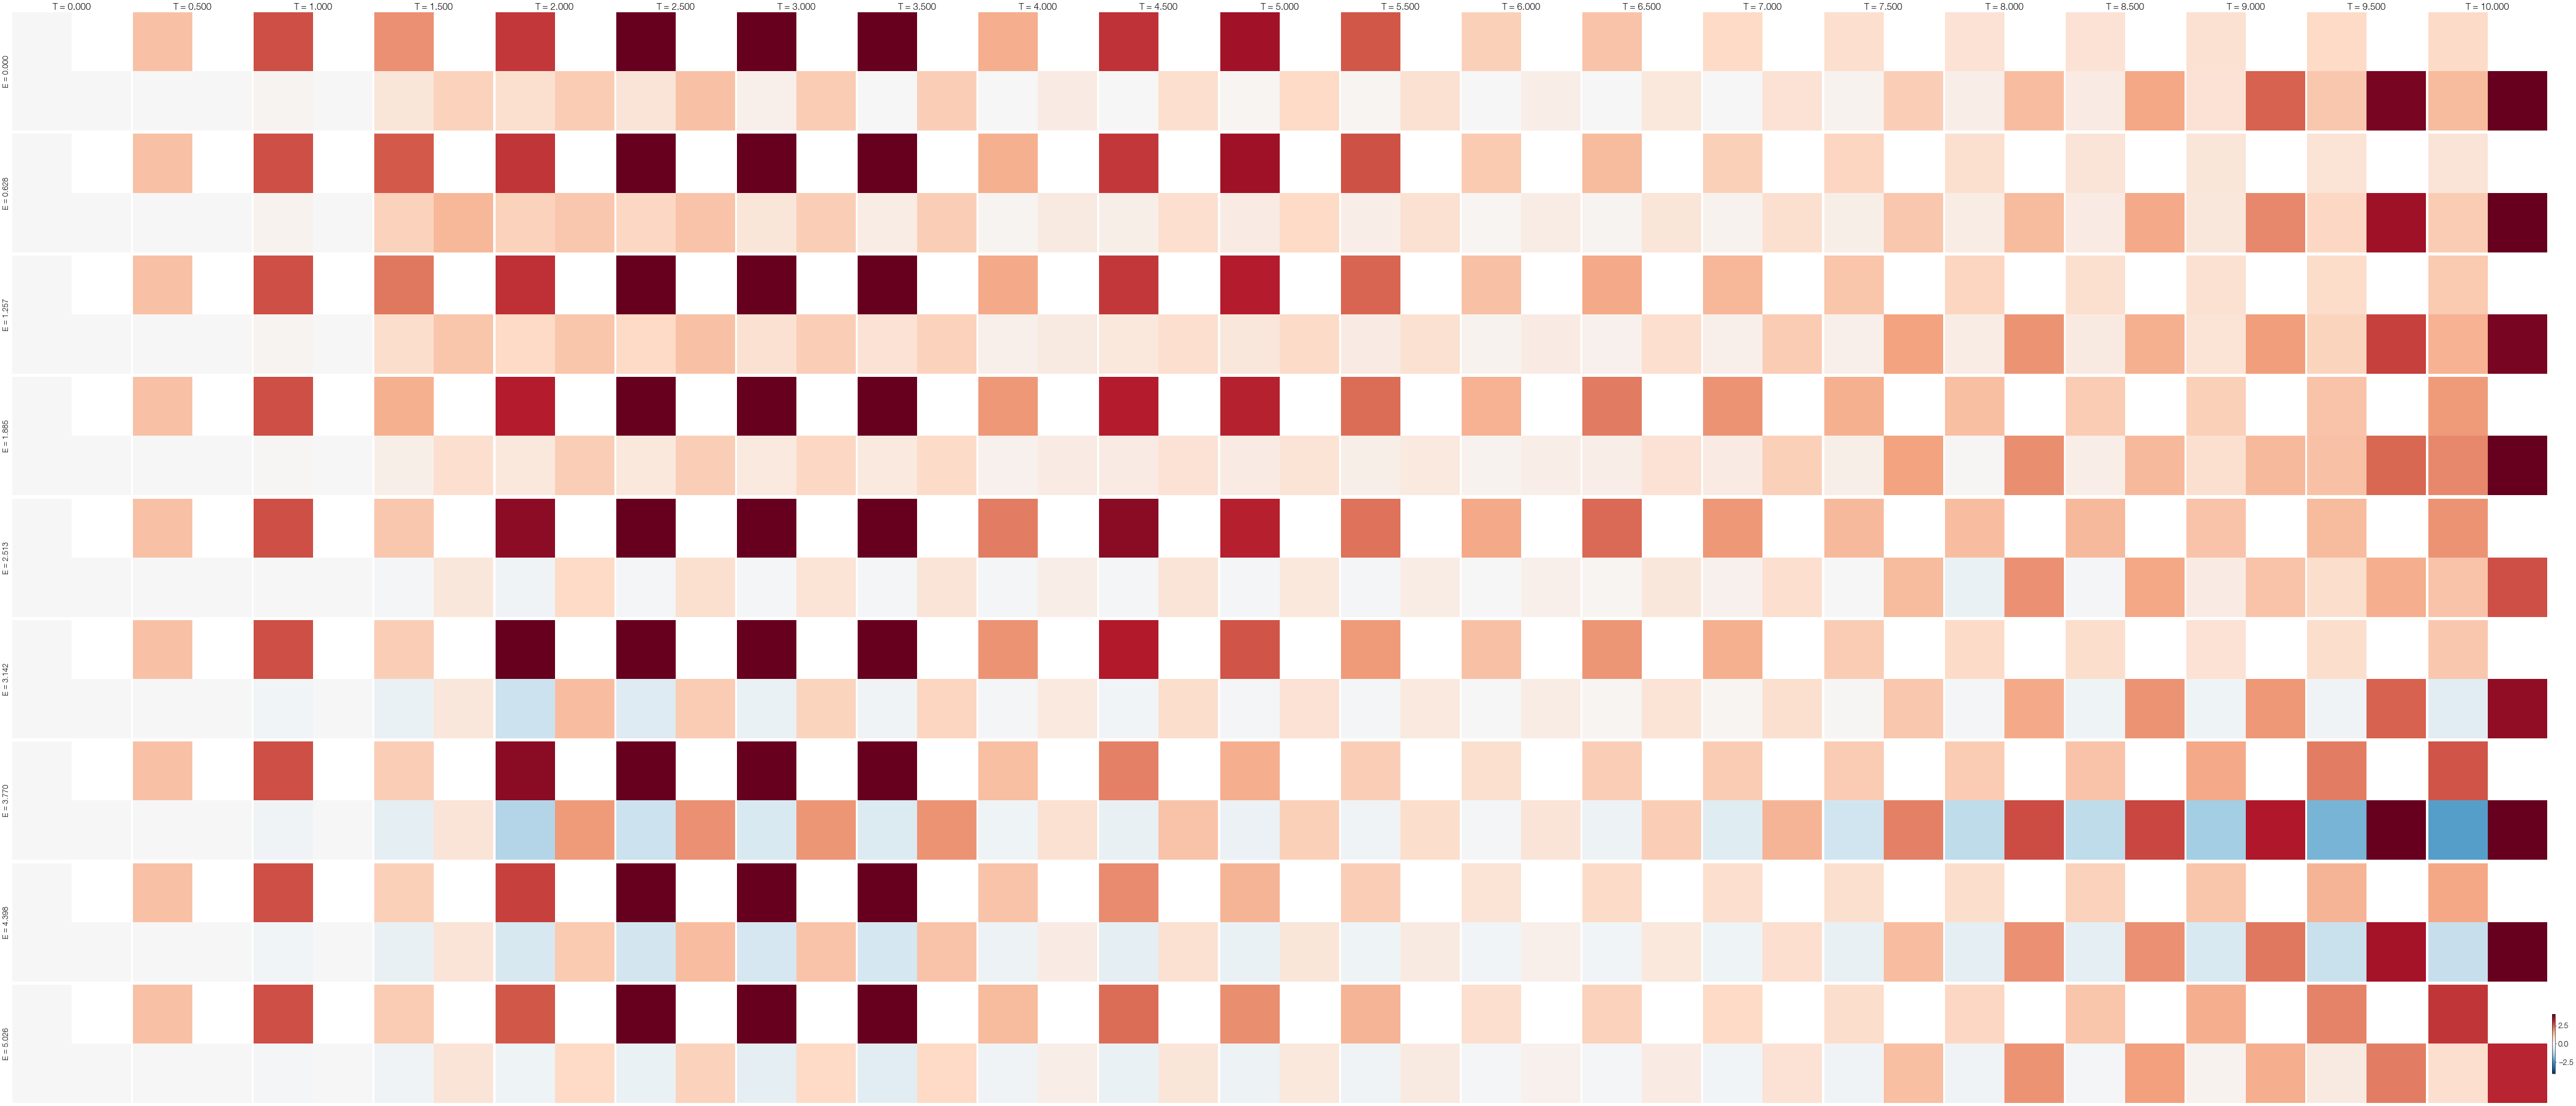

In [22]:
nb_evidence_sample, nb_ts_sample = 9, 21

axs, _, fig1 = rd.plotting.utils.get_ax_gridspec(nb_evidence_sample, nb_ts_sample, cols_3d=(), dpi=50)
time_id = 20

vmax = jnp.quantile(jnp.abs(metric[:, :, time_id]), 1.0)

for j, ax_ in enumerate(axs):
    for i, ax in enumerate(ax_):
        m = metric[i*(metric.shape[0]//(nb_evidence_sample-1)), evidence_id, j*(metric.shape[2]//(nb_ts_sample-1))]
        vmax = jnp.max(jnp.abs(m))
        m = m.at[jnp.triu_indices_from(m, k=1)].set(jnp.nan)
        im = ax.imshow(m[..., 1:, 1:], vmin=-vmax, vmax=vmax, cmap='RdBu_r')
        #ax.text(2, 0, 'T', ha='right', va='top')

        #ax.axis('off')
        utils.remove_axes(ax)
        utils.remove_ticks(ax)
        if i == 0: ax.set_title(f'T = {jnp.round(ts[delay_id][j*(metric.shape[2]//(nb_ts_sample-1))], 4):.3f}')
        if j == 0: ax.set_ylabel(f'E = {jnp.round(evidences_test[i*(metric.shape[0]//(nb_evidence_sample-1))], 4):.3f}')

plt.colorbar(im, ax=ax, shrink=0.5)

plt.savefig(f'./plots/wm_metric_t{time_id}_delay{delay_id}.pdf')
plt.show()

### Metric over torus

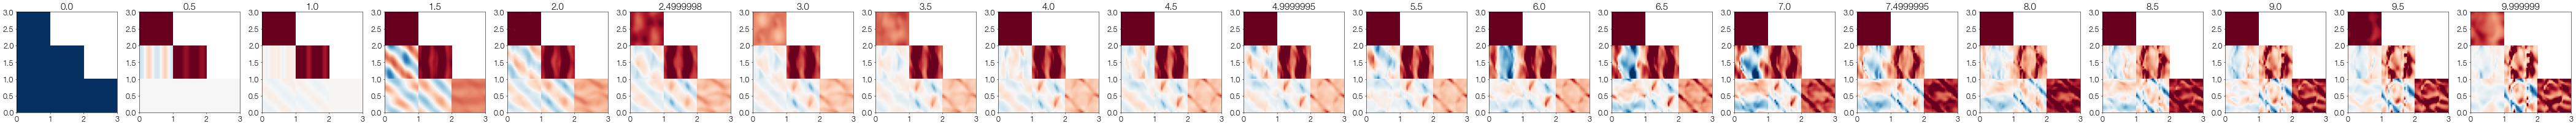

In [24]:
nb_ts_sample = 21

axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, nb_ts_sample, cols_3d=(), dpi=50)

for i, ax in enumerate(axs[:, 0]):
    vmax = jnp.quantile(jnp.abs(metric[:, :, i*(metric.shape[2]//(nb_ts_sample-1)), 1:, 1:]), 0.9)
    for j in range(3):
        for k in range(3):
            if k>=j:
                ax.set_title(ts[delay_id, i*(metric.shape[2]//(nb_ts_sample-1))])

                ax.imshow(metric[:, :, i*(metric.shape[2]//(nb_ts_sample-1)), j, k],
                          extent=[j, j+1, 3-(k+1), 3-k], vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    #utils.remove_axes(ax)
    #utils.remove_ticks(ax)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)

plt.savefig(f'./plots/metric_3d_over_time_delay{delay_id}.pdf')
plt.show()

### Metric over torus (normalised cmap entry-wise)

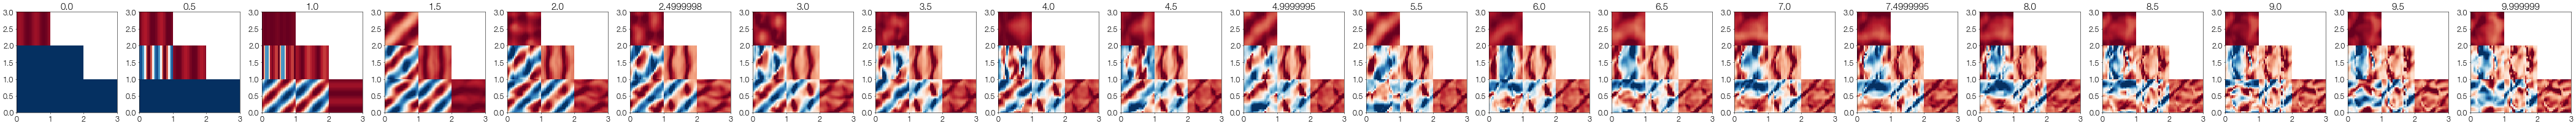

In [56]:
nb_ts_sample = 21

axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, nb_ts_sample, cols_3d=(), dpi=50)


for i, ax in enumerate(axs[:, 0]):
    idx = i * (metric.shape[2] // (nb_ts_sample - 1))

    for j in range(3):
        for k in range(3):
            if k >= j:
                data = metric[:, :, idx, j, k]
                vmax = jnp.quantile(jnp.abs(data), 0.9)

                # Grid edge coordinates (one more than resolution)
                x = np.linspace(j, j + 1, data.shape[1] + 1)
                y = np.linspace(3 - (k + 1), 3 - k, data.shape[0] + 1)

                ax.pcolormesh(x, y, data, vmin=-vmax, vmax=vmax, cmap='RdBu_r', shading='auto')

    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_title(ts[delay_id, idx])
    ax.set_aspect('equal')
    #utils.remove_axes(ax)
    #utils.remove_ticks(ax)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)

plt.savefig(f'./plots/metric_3d_over_time_norm_elementwise_delay{delay_id}.pdf')
plt.show()

### Same using imshow

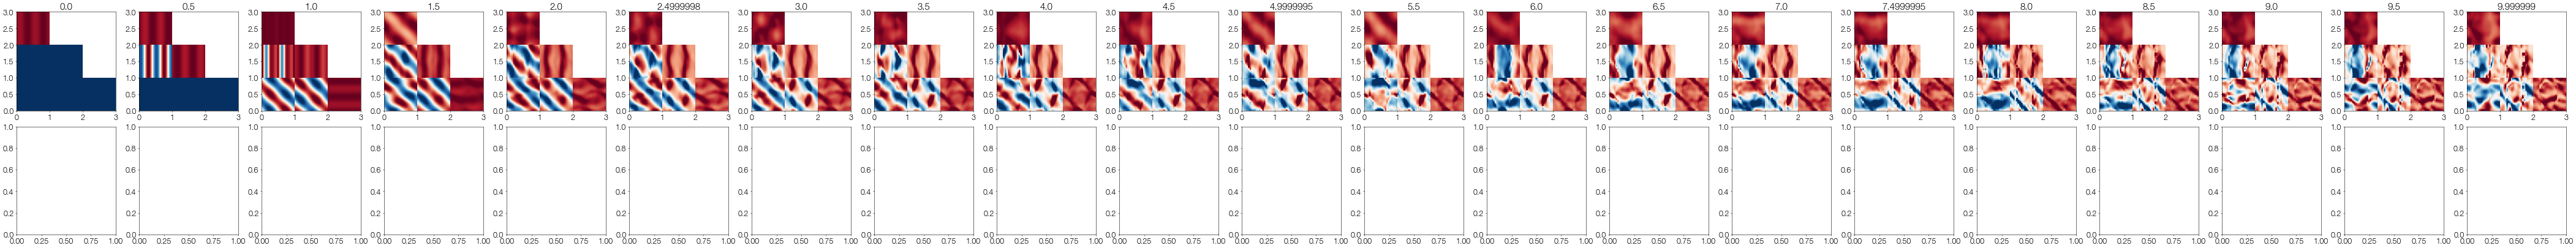

In [53]:
nb_ts_sample = 21

axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, nb_ts_sample, cols_3d=(), dpi=50)

for i, ax in enumerate(axs[:, 0]):
    vmax = jnp.quantile(jnp.abs(metric[:, :, i*(metric.shape[2]//(nb_ts_sample-1)), 1:, 1:]), 0.9)
    for j in range(3):
        for k in range(3):
            if k>=j:
                ax.set_title(ts[delay_id, i*(metric.shape[2]//(nb_ts_sample-1))])
                vmax = jnp.quantile(jnp.abs(metric[:, :, i*(metric.shape[2]//(nb_ts_sample-1)), j, k]), 0.9)
                ax.imshow(metric[:, :, i*(metric.shape[2]//(nb_ts_sample-1)), j, k],
                          extent=[j, j+1, 3-(k+1), 3-k], vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    #utils.remove_axes(ax)
    #utils.remove_ticks(ax)
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)

plt.savefig(f'./plots/metric_3d_over_time_norm_elementwise_delay{delay_id}.svg')
plt.show()

### Averaged metric

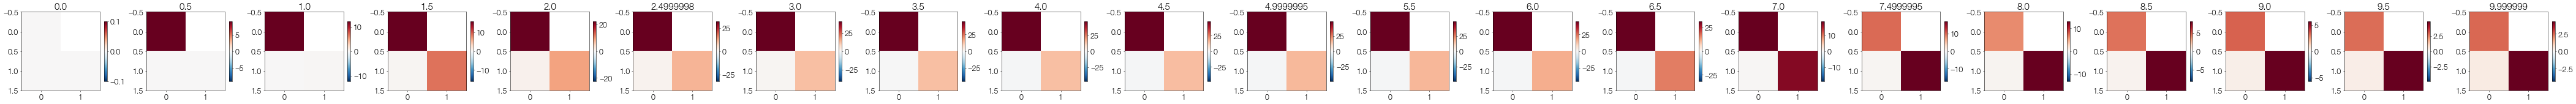

In [26]:
nb_ts_sample = 21

axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, nb_ts_sample, cols_3d=(), dpi=50)

metric_ = jnp.median(metric, axis=(0, 1))

#vmax = jnp.quantile(jnp.abs(metric_[:, 1:, 1:]), 1.0)

for i, ax in enumerate(axs[:, 0]):

    m = metric_[i*(metric.shape[2]//(nb_ts_sample-1)), 1:, 1:]

    vmax = jnp.max(jnp.abs(m))

    m = m.at[jnp.triu_indices_from(m, k=1)].set(jnp.nan)

    im = ax.imshow(m, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    ax.set_title(ts[delay_id, i*(metric.shape[2]//(nb_ts_sample-1))])
    #utils.remove_axes(ax)
    #utils.remove_ticks(ax)
    plt.colorbar(im, ax=ax, shrink=0.5)

plt.savefig(f'./plots/mean_metric_delay{delay_id}.pdf')
plt.show()

### Trace of metric

(21, 21, 51, 3, 3)


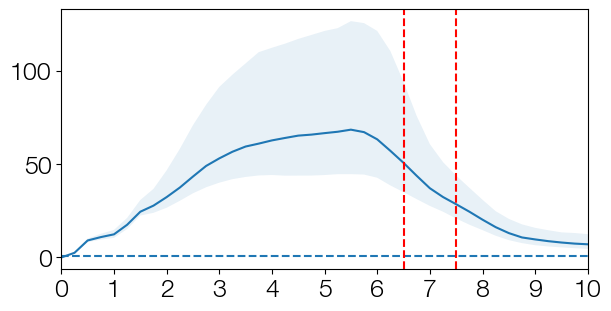

In [28]:
fig = plt.figure(figsize=(6, 3), constrained_layout=True)
ax = fig.add_subplot()
print(metric.shape)
ratio_metric_med = jnp.median(metric[:, :, :, 2, 2]+metric[:, :, :, 1, 1], axis=(0, 1))
ratio_metric_min = jnp.quantile(metric[:, :, :, 2, 2]+metric[:, :, :, 1, 1], 0.1, axis=(0, 1))
ratio_metric_max = jnp.quantile(metric[:, :, :, 2, 2]+metric[:, :, :, 1, 1], 0.9, axis=(0, 1))
ax.plot(ts[delay_id], ratio_metric_med)
ax.fill_between(ts[delay_id], ratio_metric_min, ratio_metric_max, alpha=0.1)
ax.axhline(1.0, linestyle='--')
for k in range(nb_targets):
    ax.axvline(nb_targets*target_dur+delays[delay_id]+go_duration+delay_after_go + target_dur*k,
                   linestyle='--', color=cmap(k))
#ax.plot(metric_[:, 2, 2]/metric_[:, 1, 1])
ax.set_xticks(np.arange(11))
ax.set_xlim(0, 10)

plt.savefig(f'./plots/trace_metric_delay{delay_id}.pdf')
plt.show()


### Ratio G_22 to trace

(21, 21, 51, 3, 3)


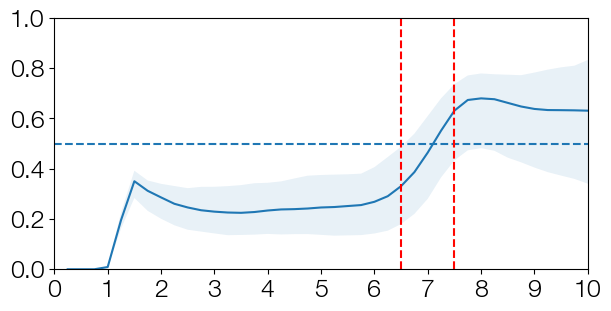

In [29]:
fig = plt.figure(figsize=(6, 3), constrained_layout=True)
ax = fig.add_subplot()
print(metric.shape)
metric_ratio = metric[:, :, :, 2, 2]/(metric[:, :, :, 1, 1]+metric[:, :, :, 2, 2])
ratio_metric_med = jnp.median(metric_ratio, axis=(0, 1))
ratio_metric_min = jnp.quantile(metric_ratio, 0.1, axis=(0, 1))
ratio_metric_max = jnp.quantile(metric_ratio, 0.9, axis=(0, 1))
ax.plot(ts[delay_id], ratio_metric_med)
ax.fill_between(ts[delay_id], ratio_metric_min, ratio_metric_max, alpha=0.1)
ax.axhline(0.5, linestyle='--')
for k in range(nb_targets):
    ax.axvline(nb_targets*target_dur+delays[delay_id]+go_duration+delay_after_go + target_dur*k,
                   linestyle='--', color=cmap(k))
#ax.plot(metric_[:, 2, 2]/metric_[:, 1, 1])
ax.set_xticks(np.arange(11))
ax.set_ylim(0, 1.0)
ax.set_xlim(0, 10)

plt.savefig(f'./plots/ratio_diagonals_metric_delay{delay_id}.pdf')
plt.show()

# Torus plotting

In [30]:
evidences_fine = jnp.linspace(0, 2*jnp.pi, 201)
evidence_input_test_fine, _, _ = get_evidence_input(*nb_targets*[evidences_fine])
#_, target_output_test_fine = get_target_output(evidence_points_test)

with jax.default_device(jax.devices("cpu")[0]):
    xs_fine = solve_vmap(random.PRNGKey(0)[None], model, go_input_delay_id,
                     evidence_input_test_fine, ts[delay_id:delay_id+1],
                     discontinuities[delay_id:delay_id+1], 0.0)[0, 0]
print(xs_fine.shape)

(201, 201, 51, 100)


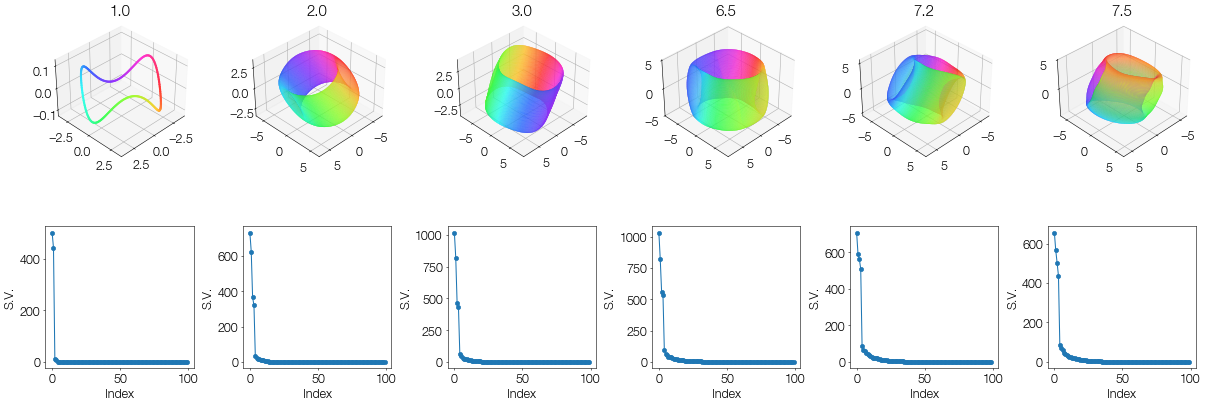

In [761]:
with jax.default_device(jax.devices("cpu")[0]):

    nb_ts_sample = 21
    ts_sampled = [1.0, 2.0, 3.0, 6.5, 7.2, 7.5]
    axs, _, fig = rd.plotting.utils.get_ax_gridspec(2, len(ts_sampled), rows_3d=(0,), dpi=50)

    for i, ax_ in enumerate(axs):

        ax = ax_[0]
        xs_ = xs_fine[:, :, jnp.argmax(ts[delay_id]>=ts_sampled[i]-10**-5)-1]
        xs_ = xs_ - xs_.mean(axis=(0, 1))

        _, S, V = jnp.linalg.svd(xs_.reshape(-1, hidden_dim), full_matrices=False)

        if i != 0:
            plotting3d.plot_manifold(ax, xs_ @ V[:3].T, cmap=cmap_manifold, gridlines=False, min_alpha=0.7, max_alpha=0.7)
        else:
            temp = xs_[0, :] @ V[:3].T
            plotting3d.plot_with_gradient_3d(ax, *temp.T, cmap=cmap_manifold, gradient=jnp.linspace(0, 1, xs_.shape[1]), set_lim=False, linewidth=3.0)
            ax.set_xlim(jnp.min(temp[:, 0])-0.5, jnp.max(temp[:, 0])+0.5)
            ax.set_ylim(jnp.min(temp[:, 1])-0.5, jnp.max(temp[:, 1])+0.5)
            ax.set_zlim(jnp.min(temp[:, 2])-0.05, jnp.max(temp[:, 2])+0.05)

        ax.view_init(35, 45, 0)

        ax.set_title(ts_sampled[i])

        ax = ax_[1]

        ax.set_title('\n\n')

        ax.plot(S, '-o')

        ax.set_xlabel('Index'), ax.set_ylabel('S.V.')

plt.savefig(f'./plots/tori_delay{delay_id}.pdf')
plt.show()

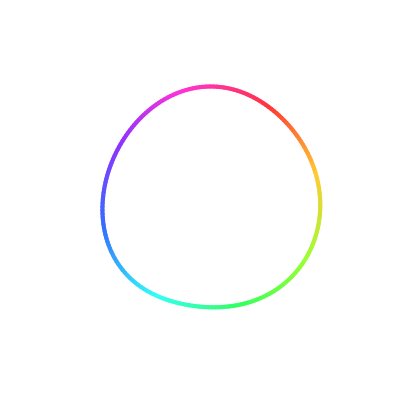

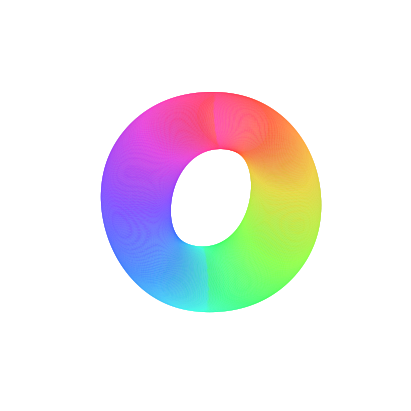

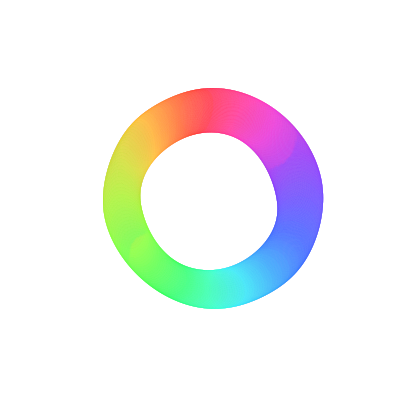

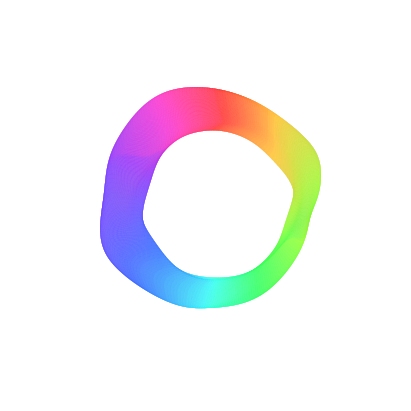

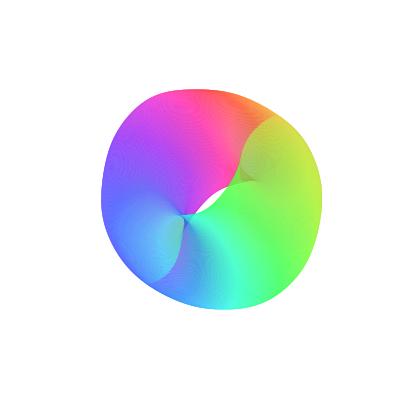

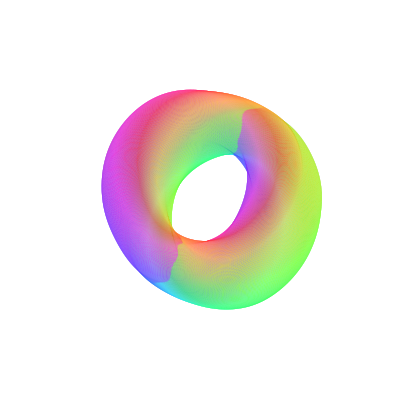

In [769]:
with jax.default_device(jax.devices("cpu")[0]):

    nb_ts_sample = 21
    ts_sampled = [1.0, 2.0, 3.0, 6.5, 7.2, 7.5]
    #axs, _, fig = rd.plotting.utils.get_ax_gridspec(2, len(ts_sampled), rows_3d=(0,), dpi=50)

    for i, t in enumerate(ts_sampled):

        fig = plt.figure(figsize=(4, 4), constrained_layout=True)
        ax = fig.add_subplot(projection='3d')

        xs_ = xs_fine[:, :, jnp.argmax(ts[delay_id]>=ts_sampled[i]-10**-5)-1]
        xs_ = xs_ - xs_.mean(axis=(0, 1))

        _, S, V = jnp.linalg.svd(xs_.reshape(-1, hidden_dim), full_matrices=False)

        if i != 0:
            plotting3d.plot_manifold(ax, xs_ @ V[:3].T, cmap=cmap_manifold, gridlines=False, min_alpha=0.7, max_alpha=0.7)
        else:
            temp = xs_[0, :] @ V[:3].T
            plotting3d.plot_with_gradient_3d(ax, *temp.T, cmap=cmap_manifold, gradient=jnp.linspace(0, 1, xs_.shape[1]), set_lim=False, linewidth=3.0)
            ax.set_xlim(jnp.min(temp[:, 0])-0.5, jnp.max(temp[:, 0])+0.5)
            ax.set_ylim(jnp.min(temp[:, 1])-0.5, jnp.max(temp[:, 1])+0.5)
            ax.set_zlim(jnp.min(temp[:, 2])-0.05, jnp.max(temp[:, 2])+0.05)

        #ax.view_init(35, 45, 0)
        ax.view_init(90, 0, 0)
        ax.axis('off')

        plt.savefig(f'./plots/tori_delay{delay_id}_t{t}_top.png', dpi=500)

check which is x and which is y

Text(0.5, 0, 'z')

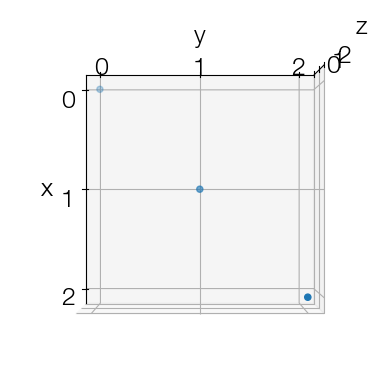

In [768]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(jnp.arange(3), jnp.arange(3), jnp.arange(3))
ax.view_init(90, 0, 0)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')


# Finite diff valid

### Finite difference metric computation

In [33]:
def compute_metric(x, dtheta, dt):
  dphi_dtheta1, dphi_dtheta2 = (jnp.roll(x, axis=0, shift=-1) - x)/dtheta, (jnp.roll(x, axis=1, shift=-1) - x)/dtheta # jnp.roll does [1,2,3,4] -> [2,3,4,1]
  if dt is not None:
      dx_dt = (x[:, :, 1:] - x[:, :, :-1])/dt
      dx_dt = jnp.concatenate([dx_dt, jnp.zeros_like(dx_dt[:, :, :1])], axis=2)


  basis = jnp.stack(([] if dt is None else [dx_dt])+[dphi_dtheta2, dphi_dtheta1], axis=-2)
  print(basis.shape)
  #basis = basis / (jnp.linalg.norm(basis, axis=-1, keepdims=True) + 10**-8)
  metric = jnp.einsum('ijkxm,ijkym->ijkxy', basis, basis)

  print(f'x {x.shape}, basis {basis.shape}, metric {metric.shape}')

  return basis, metric

#with jax.default_device(jax.devices("cpu")[0]):
#basis_fd, metric_fd = compute_metric(xs, evidences[1] - evidences[0], ts[delay_id, 1]-ts[delay_id, 0])

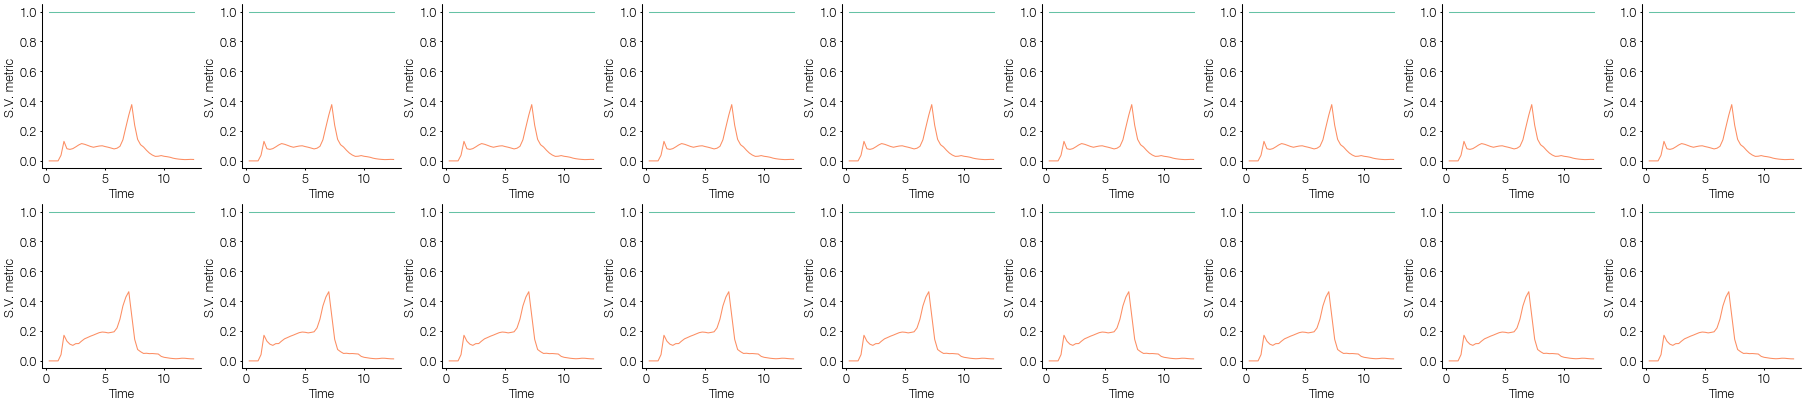

In [36]:
axs, _, fig = rd.plotting.utils.get_ax_gridspec(2, nb_evidence_sample, cols_3d=(), dpi=50)

S = jax.vmap(jax.vmap(jax.vmap(jax.vmap(partial(jnp.linalg.svd, compute_uv=False)))))(metric[None, ..., 1:, 1:])

S = S**2

cmap = matplotlib.colormaps['Set2']

for i, ax_ in enumerate(axs):
    for j, ax in enumerate(ax_):
        s = S[j, i*(nb_evidence//(nb_evidence_sample-1)) if j==0 else slice(None), i*(nb_evidence//(nb_evidence_sample-1)) if j==1 else slice(None)]

        #s = s / jnp.max(s, axis=-1, keepdims=True)

        s_med = jnp.median(s, axis=0)
        s_min = jnp.quantile(s, axis=0, q=0.05)
        s_max = jnp.quantile(s, axis=0, q=0.95)

        s_min, s_med, s_max = s_min/jnp.max(s_med, axis=1, keepdims=True), s_med/jnp.max(s_med, axis=1, keepdims=True), s_max/jnp.max(s_med, axis=1, keepdims=True)

        for k in range(s_min.shape[-1]):
            #ax.fill_between(ts[delay_id], s_min[:, k], s_max[:, k], alpha=0.2, color=cmap(k))
            ax.plot(ts[delay_id], s_med[:, k], color=cmap(k))


        ax.set_xlabel('Time')
        ax.set_ylabel('S.V. metric')

        utils.set_bottom_left_axis(ax)

utils.set_shared_lims(*axs.reshape(-1))
plt.savefig('./plots/rank_metric.pdf')
plt.show()

### Decoder alignment

In [37]:
#pushforward_basis_decoder = jax.vmap(jax.vmap(jax.vmap(jax.vmap(model.d))))(basis) / (jnp.linalg.norm(model.D, axis=-1)*jnp.linalg.norm(basis, axis=-1, keepdims=True) + 10**-8)
pushforward_decoder = jax.vmap(jax.vmap(jax.vmap(jax.jacrev(model.d))))(xs)
print(pushforward_decoder.shape, basis.shape, xs.shape)
pushforward_decoder_norm = pushforward_decoder / (jnp.linalg.norm(pushforward_decoder, axis=-1, keepdims=True) + 10**-8)
basis_norm = basis / (jnp.linalg.norm(basis, axis=-1, keepdims=True) + 10**-8)
pushforward_basis_decoder_norm = jnp.einsum('...ij,...kj->...ki', pushforward_decoder_norm, basis_norm)
#pushforward_basis_decoder_norm = 1- jnp.arccos(pushforward_basis_decoder_norm)/jnp.pi
print(pushforward_basis_decoder_norm.shape)

(21, 21, 51, 2, 100) (21, 21, 51, 3, 100) (21, 21, 51, 100)
(21, 21, 51, 3, 2)


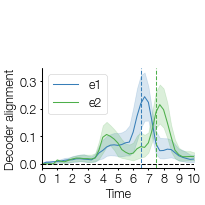

In [38]:
axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, 1, cols_3d=(), dpi=50)

pushforward_basis_decoder_norm_norm = jnp.linalg.norm(pushforward_basis_decoder_norm, axis=-1)
med_pbd = jnp.median(pushforward_basis_decoder_norm_norm, axis=(0, 1))
min_pbd = jnp.quantile(pushforward_basis_decoder_norm_norm, 0.1,  axis=(0, 1))
max_pbd = jnp.quantile(pushforward_basis_decoder_norm_norm, 0.9, axis=(0, 1))

cmap = matplotlib.colormaps['Set1']

ax = axs[0, 0]

for k, lb in enumerate(['t', 'e1', 'e2']):
    if  k != 0:
        ax.plot(ts[delay_id], med_pbd[:, k], label=lb, color=cmap(k))
        ax.fill_between(ts[delay_id], min_pbd[:, k], max_pbd[:, k], alpha=0.2, color=cmap(k))

        #ax.axvline(ts[delay_id][jnp.argmax(med_pbd[:, k])], linestyle='--', color=cmap(k))
        ax.axvline(nb_targets*target_dur+delays[delay_id]+go_duration+delay_after_go + target_dur*(k-1),
                   linestyle='--', color=cmap(k))


ax.axhline(0, linestyle='--', color='black')
#ax.set_ylim(jnp.min(pushforward_basis_decoder_norm[l, :, :, :, 1:]), jnp.max(pushforward_basis_decoder_norm[l, :, :, :, 1:]))

utils.set_bottom_left_axis(ax)

ax.set_xlabel('Time')
ax.set_ylabel('Decoder alignment')
ax.legend()
ax.set_xlim(0, 10)
ax.set_xticks(jnp.arange(11))
ax.set_title('\n\n\n')

plt.savefig(f'./plots/de_decoder_alignment_delay{delay_id}.pdf')
plt.show()

### Singular values of weight (changes)

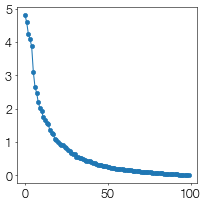

In [39]:
model_init = rnn.RNN(jax.random.PRNGKey(0), hidden_dim, input_dims, 2, jax.nn.tanh, gain)

U, S, V = jnp.linalg.svd(model.W - model_init.W)

axs, _, fig = rd.plotting.utils.get_ax_gridspec(1, 1, cols_3d=(), dpi=50)

axs[0, 0].plot(S, '-o')
plt.savefig('./plots/svd_dw.pdf')

In [40]:

def normalize(ts, min_t, max_t):

    ts = (ts - np.min(ts))
    ts = ts/(np.max(ts) - np.min(ts))
    ts = ts * (max_t - min_t)
    ts = ts + min_t

    return ts

def plot_manifold(ax, xs, cmap,
                       min_alpha=0.7, max_alpha=0.7,
                        min_alpha_grid=1.0, max_alpha_grid=1.0,
                  linewidth=2.0, edgecolor=(0.2, 0.2, 0.2),
                        gridlines=False,
                       ccount=6, rcount=6,
                       zorder=2, scatter=False, cla=True):

    if cla: ax.cla()

    #min_alpha, max_alpha = 0.0, 0.5
    alpha_decay = 1 - np.exp(np.linspace(-5, 0, xs.shape[0]))
    alpha_decay = normalize(alpha_decay, min_alpha, max_alpha)

    gradient_ts = np.concatenate([np.linspace(0, 1, xs.shape[1]-1), np.array([1.0])])
    colors = cmap(np.tile(gradient_ts, (xs.shape[0], 1)))
    colors[..., 3] = np.tile(alpha_decay, (xs.shape[1], 1)).T
    colors[..., 3] = min_alpha

    if scatter:
        colors = cmap(np.tile(gradient_ts, (xs.shape[0], 1))).reshape(-1, 4)
        colors[..., 3] = 0.1
        ax.scatter(xs[..., 0].reshape(-1), xs[..., 1].reshape(-1), xs[..., 2].reshape(-1),
                        c=colors,
                        edgecolor=None,
                        s=100,
                        zorder=zorder)

    else:
        ax.plot_surface(xs[..., 0], xs[..., 1], xs[..., 2],
                        facecolors=colors,
                        linewidth=0.02,
                        ccount=xs.shape[0], rcount=xs.shape[1],
                        shade=False,
                        #alpha=0.1,
                        zorder=zorder)

    if gridlines:
        # ===== Grid lines =====
        #min_alpha_grid, max_alpha_grid = 0.0, 1.0
        alpha_decay = 1 - np.exp(np.linspace(-5, 0, xs.shape[0]))
        alpha_decay = normalize(alpha_decay, min_alpha, max_alpha)

        #colors[..., 3] = np.tile(alpha_decay, (xs.shape[1], 1))

        #cmap = utils.set_saturation(cmap, 0.9)
        #gradient_ts = np.linspace(0, 1, xs.shape[1])
        colors = cmap(np.tile(gradient_ts, (xs.shape[0], 1)))
        #colors[..., 3] = np.tile(alpha_decay, (xs.shape[1], 1)).T
        colors[..., 3] = min_alpha_grid

        cmap_alpha = utils.get_cmap_interpolated(*colors[0, :])
        # ====== Lines =====
        for i in range(0, xs.shape[0], xs.shape[0]//rcount):
            plotting3d.plot_with_gradient_3d(ax, xs[i, :, 0], xs[i, :, 1], xs[i, :, 2], linewidth=linewidth,
                                        gradient=gradient_ts, cmap=cmap_alpha, set_lim=False, zorder=zorder+0.5, alpha=None)

        #cmap_alpha = utils.get_cmap_interpolated(*colors[0, :])
        # ====== Circle =====
        for i in range(0, xs.shape[1], xs.shape[1]//ccount):
            #ax.plot(xs[:, i, 0], xs[:, i, 1], xs[:, i, 2], zorder=zorder+0.5, color=colors[0, i])
            cmap_ = utils.get_cmap_interpolated(colors[0, i], colors[0, i])
            plotting3d.plot_with_gradient_3d(ax, xs[:, i, 0], xs[:, i, 1], xs[:, i, 2], linewidth=linewidth,
                                        gradient=np.ones(xs.shape[0]), cmap=cmap_, set_lim=False, zorder=zorder + 0.5,
                                        alpha=None)
        #ax.plot(xs[:, -1, 0], xs[:, -1, 1], xs[:, -1, 2], zorder=zorder+0.5, color=colors[0, -1, :3])


### Pullback metric

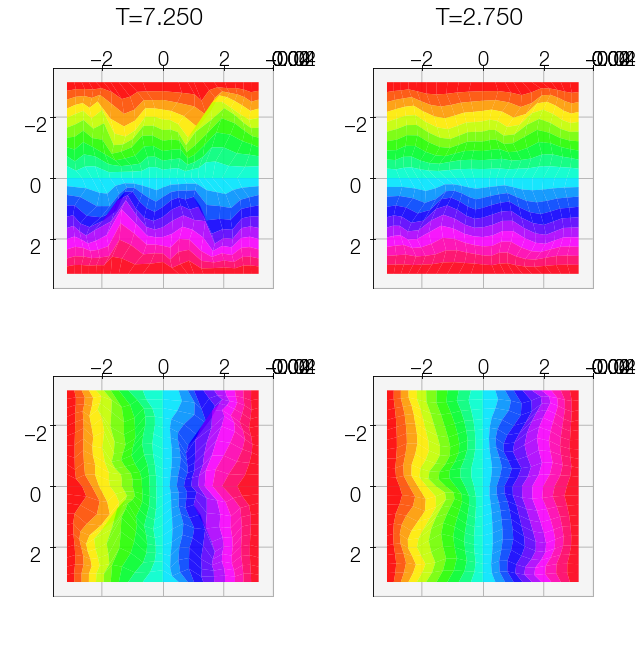

In [41]:
axs, _, fig = rd.plotting.utils.get_ax_gridspec(2, 2, cols_3d=(0, 1, 2, 3), dpi=80)

#metric = metric[0]

integrated_metric_e1 = jnp.cumsum(metric[..., 1, 1], axis=0)
integrated_metric_e2 = jnp.cumsum(metric[..., 2, 2], axis=1)

integrated_metric = jnp.stack([integrated_metric_e1, integrated_metric_e2], axis=-1)

integrated_metric = jnp.stack(2*[integrated_metric])

view_init1 = (75, -120, -120)
view_init2 = (90, 0, 0)

# =========== t_max ==============
time_id = jnp.argmax(ts>nb_targets*target_dur+delays[delay_id])

m = jnp.stack([integrated_metric[..., 0], integrated_metric[..., 1], jnp.zeros_like(integrated_metric[..., 1])], axis=-1)
m = np.array(m)

m[:, :, :, :, :1] -= (m[:, m.shape[1]//2:m.shape[1]//2+1, :, :, :1] + 10**-6)
m[:, :, :, :, 1:2] -= (m[:, :, m.shape[2]//2:m.shape[2]//2+1, :, 1:2] + 10**-6)

m[:, :m.shape[1]//2, :, :, :1] /= m[:, :1, :, :, :1]/(-np.pi) + 10**-6
m[:, :, :m.shape[2]//2, :, 1:2] /= m[:, :, :1, :, 1:2]/(-np.pi) + 10**-6

m[:, m.shape[1]//2:, :, :, :1] /= m[:, -1:, :, :, :1]/np.pi + 10**-6
m[:, :, m.shape[2]//2:, :, 1:2] /= m[:, :, -1:, :, 1:2]/np.pi + 10**-6

m1 = m[0, :, :, time_id].transpose(1, 0, 2)
m2 = m[1, :, :, time_id]

plot_manifold(axs[0, 0], m1, cmap=cmap_e1, gridlines=False, min_alpha=0.9)
plot_manifold(axs[0, 1], m2, cmap=cmap_e2, gridlines=False, min_alpha=0.9)

axs[0, 0].set_title(f'T={ts[delay_id, time_id]:.3f}')

# =========== t_min ==============

time_id = jnp.argmax(ts>nb_targets*target_dur)

m1 = m[0, :, :, time_id].transpose(1, 0, 2)
m2 = m[1, :, :, time_id]

plot_manifold(axs[1, 0], m1, cmap=cmap_e1, gridlines=False, min_alpha=0.9)
plot_manifold(axs[1, 1], m2, cmap=cmap_e2, cla=False, gridlines=False, min_alpha=0.9)

axs[1, 0].set_title(f'T={ts[delay_id, time_id]:.3f}')

for ax_ in axs:
    for ax in ax_:
        ax.set_aspect('equal')
        ax.view_init(90, 0)
        #ax.axis('off')

plt.savefig(f'./plots/metric_e1_e2_pullback_delay{delay_id}.pdf')
plt.show()

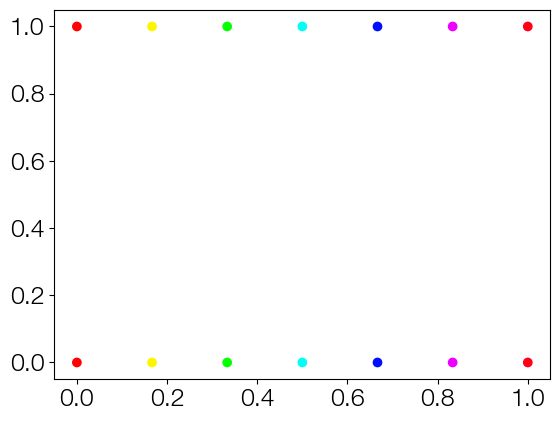

In [42]:
k = 7
plt.scatter(jnp.linspace(0, 1, k), jnp.zeros(k), color=cmap_e1(jnp.linspace(0, 1, k)))
plt.scatter(jnp.linspace(0, 1, k), jnp.ones(k), color=cmap_e2(jnp.linspace(0, 1, k)))
plt.show()

### Gaussian curvature

In [43]:
def fd(x, dt, i):

    return (x - jnp.roll(x, axis=i, shift=-1)) / dt

def finite_difference_gaussian_curvature(xs, thetas):

    dt = thetas[1]-thetas[0]

    basis = jnp.stack([fd(xs, dt, 0), fd(xs, dt, 1)], axis=-2)

    metric = jnp.einsum('...ij,...kj->...ik', basis, basis)

    det = jnp.linalg.det(metric)
    sqrt_det = jnp.sqrt(det) + 10**-5

    k1 = (fd(metric[..., 0, 1], dt, 1) - fd(metric[..., 1, 1], dt, 0)/2)/sqrt_det
    k2 = (fd(metric[..., 0, 1], dt, 0) - fd(metric[..., 0, 0], dt, 1)/2)/sqrt_det

    K = (fd(k1, dt, 0) + fd(k2, dt, 1))/sqrt_det

    return K

In [426]:
t_time = nb_targets*target_dur+delays[delay_id]/2+go_duration+delay_after_go
t_time = 2.0
time_id = jnp.argmax(ts[delay_id]>=t_time)
print(ts[delay_id, time_id])

K = finite_difference_gaussian_curvature(xs_fine[:-1, :-1, time_id], evidences_fine)

2.0


In [430]:
def generate_torus(mesh_size, R=1.5, r=0.5):

    u = jnp.linspace(0, 2 * jnp.pi, mesh_size)
    v = jnp.linspace(0, 2 * jnp.pi, mesh_size)
    u, v = jnp.meshgrid(u, v)

    x = (R + r * jnp.cos(v)) * jnp.cos(u)
    y = (R + r * jnp.cos(v)) * jnp.sin(u)
    z = r * jnp.sin(v)

    torus = jnp.stack([x, y, z], axis=-1)
    return torus


def generate_plane(mesh_size, v1, v2, b):

    # Convert inputs to numpy arrays if they aren't already
    v1 = np.array(v1, dtype=float)
    v2 = np.array(v2, dtype=float)
    b = np.array(b, dtype=float)

    # Create parameter grid
    u = np.linspace(-1, 1, mesh_size)
    v = np.linspace(-1, 1, mesh_size)

    # Create meshgrid for the parameters
    u_grid, v_grid = np.meshgrid(u, v)

    # Initialize the mesh with the right shape
    mesh = np.zeros((mesh_size, mesh_size, 3))

    # Compute the mesh points
    for i in range(mesh_size):
        for j in range(mesh_size):
            # Each point is a linear combination of the vectors plus the offset
            mesh[i, j] = u_grid[i, j] * v1 + v_grid[i, j] * v2 + b

    return jnp.array(mesh)


In [431]:
standard_torus = generate_torus(K.shape[0])

In [432]:
plane = generate_plane(K.shape[0], [1, 0, 0], [0, 1, 0], [0, 0, 0])

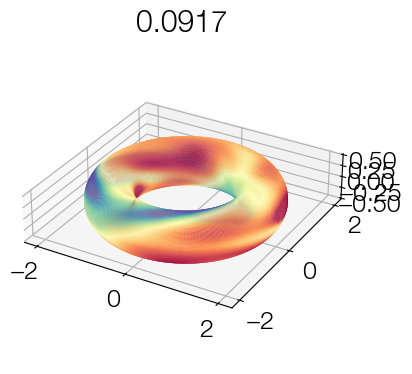

In [433]:
fig = plt.figure(figsize=(4, 4), constrained_layout=True)
ax = fig.add_subplot(projection='3d')

K_quant = jnp.quantile(jnp.abs(K), 0.9)
K_max = jnp.max(jnp.abs(K))

cmap_gauss = matplotlib.colormaps['Spectral_r']

normalized_K = 0.5+0.5*K/K_quant
colors = cmap_gauss(normalized_K)

#colors[..., 3] = 0.8

ax.plot_surface(*standard_torus.transpose(2, 0, 1), facecolors=colors, linewidth=0.02,
                shade=False, rcount=K.shape[0], ccount=K.shape[1])

ax.set_aspect('equal')
ax.set_title(f'{K_quant:.4f}')

plt.savefig('./plots/gaussian_curvature.pdf')
plt.show()

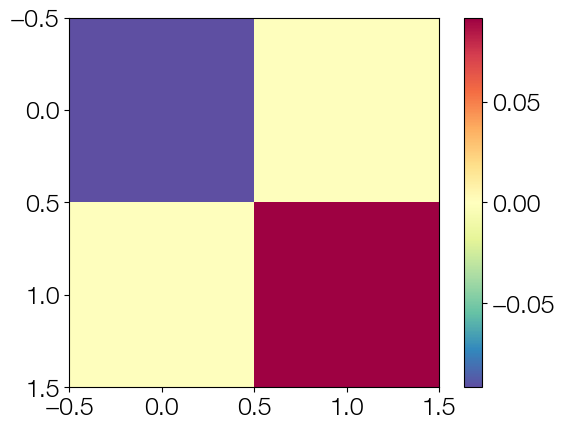

In [434]:
fig = plt.figure()
ax = fig.add_subplot()
im = ax.imshow([[-K_quant, 0], [0, K_quant]], cmap=cmap_gauss)
plt.colorbar(im)

plt.savefig('./plots/colorbar_gauss.pdf')
plt.show()

### Piece of torus

[3 7]
[15.678651    7.4014816   1.3415866   0.7276967   0.26502535]
(19, 19, 1, 2, 3)
x (19, 19, 1, 3), basis (19, 19, 1, 2, 3), metric (19, 19, 1, 2, 2)
(1, 1, 1, 2, 3) (19, 19, 3) (19, 19, 1, 2, 3)


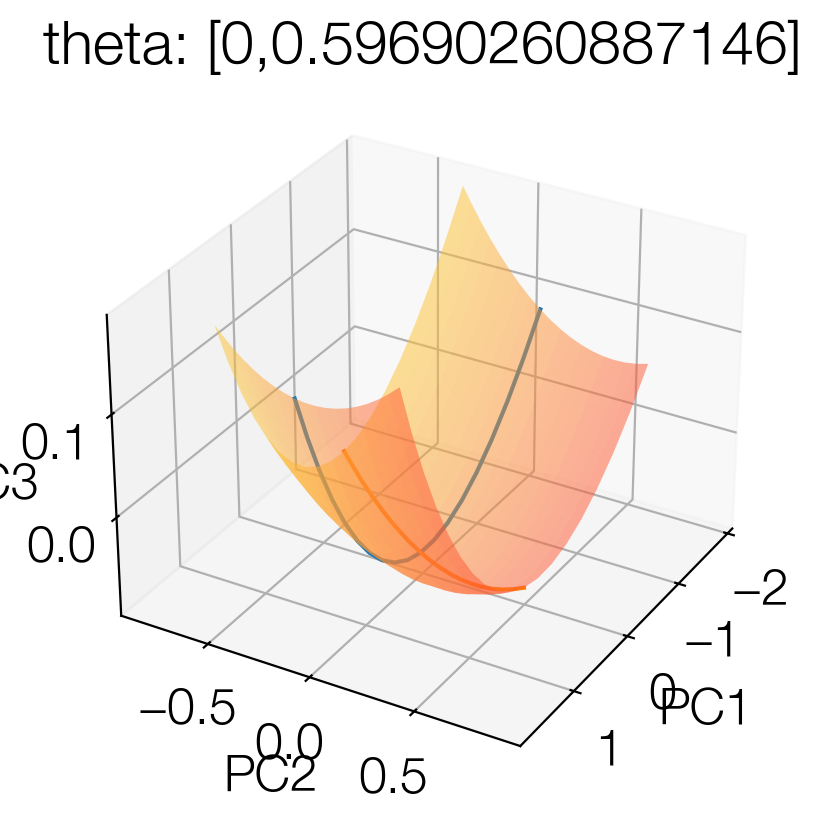

In [513]:
def plot_vector_fields(ax, xs, vfs, cmap=matplotlib.colormaps['Set2'], alpha=1.0):

    xs.reshape(-1, xs.shape[-1])

    for i, vf in enumerate(vfs.transpose(2, 0, 1, 3)):
        xs_ = xs.reshape(-1, xs.shape[-1]).T
        vf_ = vf.reshape(-1, vf.shape[-1]).T
        vf_ = np.stack([xs_, xs_ + vf_], axis=-2)
        for vf in vf_.transpose(2, 0, 1):
            ax.plot(*vf, color=cmap(i), linewidth=1.5, alpha=alpha)


fig = plt.figure(figsize=(4, 4), dpi=200, constrained_layout=True)
ax = fig.add_subplot(projection='3d')

xs_ = xs_fine[:, :, time_id]

import scipy

K_smooth = K#scipy.ndimage.gaussian_filter(K, sigma=(3, 3), axes=(0, 1), mode='wrap')
K_min_id = jnp.concatenate(jnp.argwhere(jnp.min(K_smooth)==K_smooth))
K_max_id = jnp.concatenate(jnp.argwhere(jnp.max(K_smooth)==K_smooth))
K_zero_id = jnp.concatenate(jnp.argwhere(jnp.min(jnp.abs(K_smooth))==jnp.abs(K_smooth)))
piece_start = K_max_id
xs_ = jnp.roll(jnp.roll(xs_, axis=0, shift=-piece_start[0]), axis=1, shift=-piece_start[1])
piece_size = 19

print(piece_start)

xs_ = xs_[:piece_size, :piece_size]

xs_ = xs_ - xs_.mean(axis=(0, 1))
_, S, V = jnp.linalg.svd(xs_.reshape(-1, hidden_dim), full_matrices=False)
print(S[:5])
xs_proj = xs_ @ V[:3].T

cmap_temp = utils.get_cmap_interpolated(*cmap_manifold(evidences_fine[piece_start[1]:piece_start[1]+piece_size]/(jnp.pi*2)))
xs_proj = jnp.swapaxes(xs_proj, 0, 1)
plotting3d.plot_manifold(ax, xs_proj, cmap=cmap_temp, gridlines=False, min_alpha=0.5, max_alpha=0.5)
#plot_vector_fields(ax, xs_[::2, ::2] @ V[:3].T, basis_fd[::2, ::2][..., time_id, :, :] @ V[:3].T, alpha=0.3)
#plot_vector_fields(ax, xs_[:piece_size:2, :piece_size:2] @ V[:3].T, basis_fd[:piece_size:2, :piece_size:2][..., time_id, :, :] @ V[:3].T, alpha=0.3)
basis_fd_piece, metric_fd_piece = compute_metric(xs_proj[:, :, None], evidences_fine[1] - evidences_fine[0], None)

ax.plot(*xs_proj[:, piece_size//2+1].T)
ax.plot(*xs_proj[piece_size//2+1].T)

point_ids = lambda x: x[piece_size//2+1:piece_size//2+2, piece_size//2+1:piece_size//2+2]

print(point_ids(basis_fd_piece).shape, xs_proj.shape, basis_fd_piece.shape)
#plot_vector_fields(ax, point_ids(xs_proj), point_ids(basis_fd_piece)[:, :, 0], alpha=0.8)

ax.set_title(f'theta: [0,{evidences_fine[piece_size]}]')
#ax.set_aspect('equal')
ax.view_init(30, 30, 0)
#ax.axis('off')
ax.set_xlabel('PC1'), ax.set_ylabel('PC2'), ax.set_zlabel('PC3')

plt.savefig('./plots/finite_diff_tangent_space_max_principal.pdf')
plt.show()

### Where the piece is

In [519]:
print(evidences_fine[K_max_id[0]],
      evidences_fine[K_max_id[1]],
      evidences_fine[K_min_id[0]],
      evidences_fine[K_min_id[1]],)

0.09424779 0.2199115 2.638938 5.811947


### Checking the Gaussian curvature finite diff

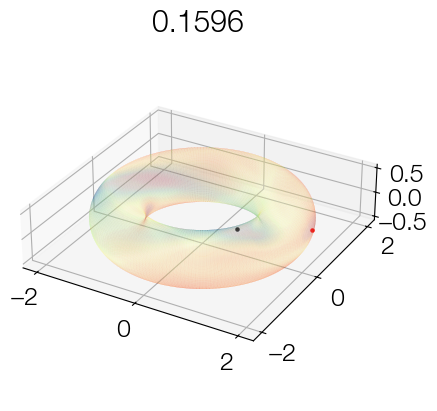

In [452]:
fig = plt.figure(figsize=(4, 4), constrained_layout=True)
ax = fig.add_subplot(projection='3d')

K_quant = jnp.quantile(jnp.abs(K), 0.99)
K_max = jnp.max(jnp.abs(K))

cmap_gauss = matplotlib.colormaps['Spectral_r']

normalized_K = 0.5+0.5*K/K_quant
colors = cmap_gauss(normalized_K)

colors[..., 3] = 0.2

ax.plot_surface(*standard_torus.transpose(2, 0, 1), facecolors=colors, linewidth=0.02,
                shade=False, rcount=K.shape[0], ccount=K.shape[1])

ax.scatter(*standard_torus[*K_min_id].T, s=5, color='black')
ax.scatter(*standard_torus[*K_max_id].T, s=5, color='red')
ax.set_aspect('equal')
ax.set_title(f'{K_quant:.4f}')

plt.show()

In [444]:
def generate_saddle_mesh(x_range=(-2, 2), y_range=(-2, 2), resolution=100):
    """
    Generate the meshgrid and corresponding Z values for a saddle surface.

    Parameters:
        x_range (tuple): Range of x values, e.g., (-2, 2)
        y_range (tuple): Range of y values, e.g., (-2, 2)
        resolution (int): Number of points along each axis

    Returns:
        X, Y, Z: Meshgrid arrays for the saddle surface
    """
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)
    Z = X**2 - Y**2
    return jnp.stack([X, Y, Z], axis=-1)

def generate_paraboloid_mesh(x_range=(-2, 2), y_range=(-2, 2), resolution=100):
    """
    Generate the meshgrid and corresponding Z values for a paraboloid surface.

    Parameters:
        x_range (tuple): Range of x values, e.g., (-2, 2)
        y_range (tuple): Range of y values, e.g., (-2, 2)
        resolution (int): Number of points along each axis

    Returns:
        X, Y, Z: Meshgrid arrays for the paraboloid surface
    """
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)
    Z = X**2 + Y**2
    return jnp.stack([X, Y, Z], axis=-1)

def generate_sinusoid_mesh(x_range=(-2 * np.pi, 2 * np.pi), y_range=(-2 * np.pi, 2 * np.pi), resolution=200):
    """
    Generate the meshgrid and corresponding Z values for a sinusoidal (wavelet-like) surface.

    Parameters:
        x_range (tuple): Range of x values, e.g., (-2π, 2π)
        y_range (tuple): Range of y values, e.g., (-2π, 2π)
        resolution (int): Number of points along each axis

    Returns:
        X, Y, Z: Meshgrid arrays for the sinusoidal surface
    """
    x = np.linspace(*x_range, resolution)
    y = np.linspace(*y_range, resolution)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X) * np.cos(Y)
    return jnp.stack([X, Y, Z], axis=-1)

example_manifolds = [generate_saddle_mesh(), generate_paraboloid_mesh(), generate_sinusoid_mesh()]
example_Ks = [finite_difference_gaussian_curvature(x, jnp.linspace(0, 1))[:-3, :-3] for x in example_manifolds]
example_manifolds = [x[:-3, :-3] for x in example_manifolds]

In [445]:
#K_saddle = finite_difference_gaussian_curvature(example_manifold, jnp.linspace(0, 1))[:-3, :-3]

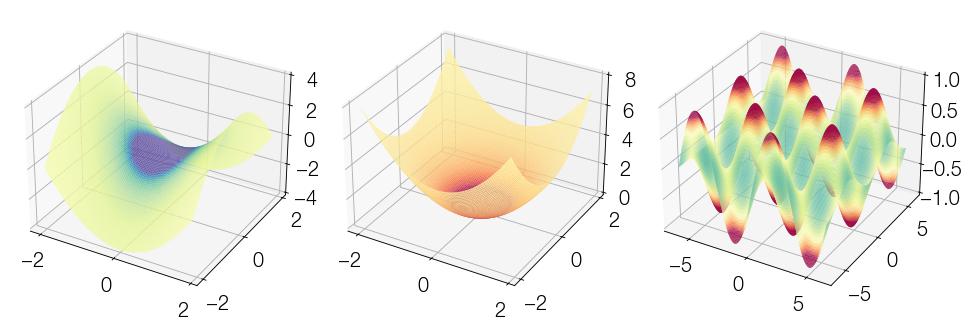

In [446]:
#plane_mesh = generate_plane(K_saddle.shape[0], [1, 0, 0], [0, 1, 0], [0, 0, 0])

axs, _, _ = utils.get_ax_gridspec(1, len(example_manifolds), rows_3d=(0,), dpi=80)

#K_saddle_quant = jnp.quantile(jnp.abs(K_saddle), 0.9)
#K_saddle_max = jnp.max(jnp.abs(K_saddle))

cmap_gauss = matplotlib.colormaps['Spectral_r']

colors[..., 3] = 0.8

#colors[..., 3] = 0.8

for i, ax in enumerate(axs[:, 0]):

    x_ = example_manifolds[i]
    K_ = example_Ks[i]

    K_quant_ = jnp.quantile(jnp.abs(K_), 0.9)
    K_max_ = jnp.max(jnp.abs(K_))

    normalized_K_ = 0.5+0.5*K_/K_quant_
    colors = cmap_gauss(normalized_K_)
    colors[..., 3] = 0.9

    ax.plot_surface(*x_.transpose(2, 0, 1), facecolors=colors, linewidth=0.02,
                shade=False, rcount=K_.shape[0], ccount=K_.shape[1])

plt.savefig('./plots/example_manifolds_gaussian_curvature.pdf')
plt.show()

# Subspace similarity

### Subspace similarity

In [638]:
def get_xs_fine_fine():
    evidences_test = jnp.linspace(min_evidence, max_evidence, 51)[:-1]

    evidence_input_test, _, evidence_points_test = get_evidence_input(*nb_targets*[evidences_test])
    _, target_output_test = get_target_output(evidence_points_test)

    ts_test = jax.vmap(lambda t: jnp.linspace(0.0, t, 201))(max_times)

    return ts_test, solve_vmap(random.PRNGKey(0)[None], model, go_input, evidence_input_test, ts_test, discontinuities, 0.0)[0]

with jax.default_device(jax.devices("cpu")[0]):

    ts_fine, xs_fine_fine = get_xs_fine_fine()

In [686]:
def subspace_similarity_spec(V1, V2):

    cov = V2 @ V1.T

    S = jnp.linalg.svd(cov, full_matrices=False, compute_uv=False)

    return S[0]#/jnp.sum(S)

def subspace_similarity_nuc(V1, V2):

    cov = V2 @ V1.T

    S = jnp.linalg.svd(cov, full_matrices=False, compute_uv=False)

    return jnp.sum(S)/len(S)

In [715]:
def left_sv(x, R=2):

    _, _, V = jnp.linalg.svd(x.reshape(-1, x.shape[-1]), full_matrices=False)

    return V[:R]

In [722]:
def plot_similarities(t, x):

    xs_V = jax.vmap(left_sv, in_axes=2, out_axes=0)(x)
    similarity_spec = jax.vmap(jax.vmap(subspace_similarity_spec, in_axes=(0, None)), in_axes=(None, 0))(xs_V, xs_V)
    similarity_nuc = jax.vmap(jax.vmap(subspace_similarity_nuc, in_axes=(0, None)), in_axes=(None, 0))(xs_V, xs_V)

    axs, _, _ = utils.get_ax_gridspec(1, 2)

    axs = axs[:, 0]

    im = axs[0].imshow(similarity_spec, extent=[0, t[-1], 0, t[-1]], vmin=0, vmax=1, cmap='magma', origin='lower', interpolation='none')
    axs[0].set_title('Spectral similarity')
    plt.colorbar(im, ax=axs[0], shrink=0.5)

    im = axs[1].imshow(similarity_nuc, extent=[0, t[-1], 0, t[-1]], vmin=0, vmax=1, cmap='magma', origin='lower', interpolation='none')
    axs[1].set_title('Nuclear similarity')
    plt.colorbar(im, ax=axs[1], shrink=0.5)

    axs[1].axvline(nb_targets*target_dur)
    axs[1].axhline(nb_targets*target_dur)
    #axs[1].axvline(go_times[1])
    #axs[1].axhline(go_times[1])

    for ax in axs:
        ax.set_aspect('equal')
        ax.set_xlabel('Time'), ax.set_ylabel('Time')

    return axs


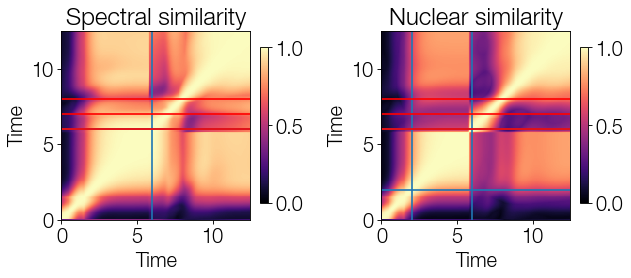

In [723]:
d_id = -1

with jax.default_device(jax.devices("cpu")[0]):

    axs = plot_similarities(ts_fine[d_id], xs_fine_fine[d_id])

for ax in axs:
    ax.axvline(go_times[d_id, 2])
    ax.axhline(go_times[d_id, 2])

    ax.axhline(6, color='red')
    ax.axhline(7, color='red')
    ax.axhline(8, color='red')

plt.savefig(f'./plots/subspace_similarities_full_delay{d_id}.pdf')
plt.show()

In [724]:
go_times[d_id, 1]

Array(5.5, dtype=float32)

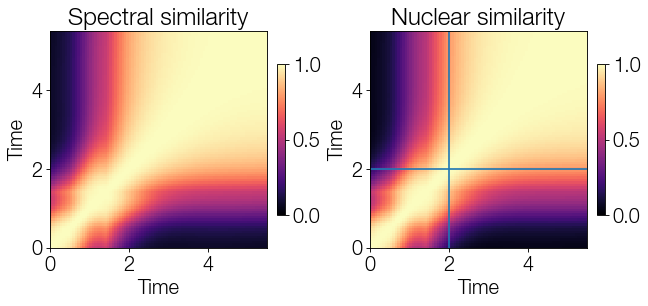

In [770]:
mask = (ts_fine[-1] > 0) & (ts_fine[-1]<=(nb_targets*target_dur + delays[-1]))

with jax.default_device(jax.devices("cpu")[0]):

    plot_similarities(ts_fine[-1][mask], xs_fine_fine[-1][:, :, mask])

plt.savefig('./plots/subspace_similarities_delay.pdf')
plt.show()